<a href="https://colab.research.google.com/github/VadimFilips/ProjectFilipsGit/blob/main/%D0%97%D0%B0%D0%B4%D0%B0%D0%BD%D0%B8%D0%B5%20%E2%84%966/%D0%97%D0%B0%D0%B4%D0%B0%D0%BD%D0%B8%D0%B5_%E2%84%966.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Установка библиотеки pmdarima
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 36.6 MB/s eta 0:00:00


ОПИСАНИЕ КОЛОНОК ДАТАСЕТА (USGS Earthquake Database)
Date                : Дата землетрясения в формате MM/DD/YYYY
Time                : Время землетрясения в формате HH:MM:SS
Latitude            : Широта эпицентра землетрясения (градусы)
Longitude           : Долгота эпицентра землетрясения (градусы)
Type                : Тип сейсмического события (Earthquake, Explosion и т. д.)
Depth               : Глубина гипоцентра землетрясения (км)
Magnitude           : Магнитуда землетрясения по шкале Рихтера
Magnitude Type      : Тип шкалы измерения магнитуды (ML, Mb, Ms, Mw и др.)
ID                  : Уникальный идентификатор события
Source              : Источник данных о землетрясении
Location Source     : Источник информации о местоположении
Magnitude Source    : Источник информации о магнитуде
Status              : Статус события (Reviewed или Automatic)

ОСНОВНЫЕ ХАРАКТЕРИСТИКИ ДАТАСЕТА
                 Характеристика   Значение
             Количество записей     23,412
             Ко

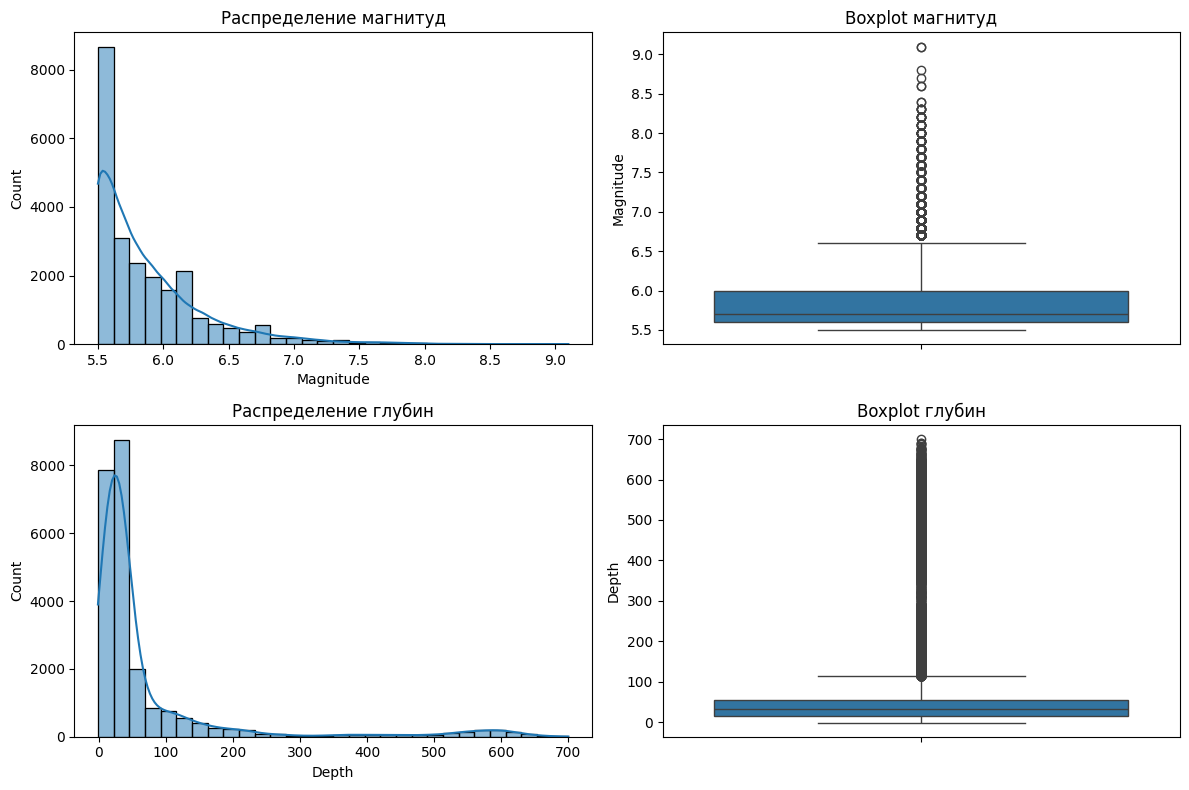

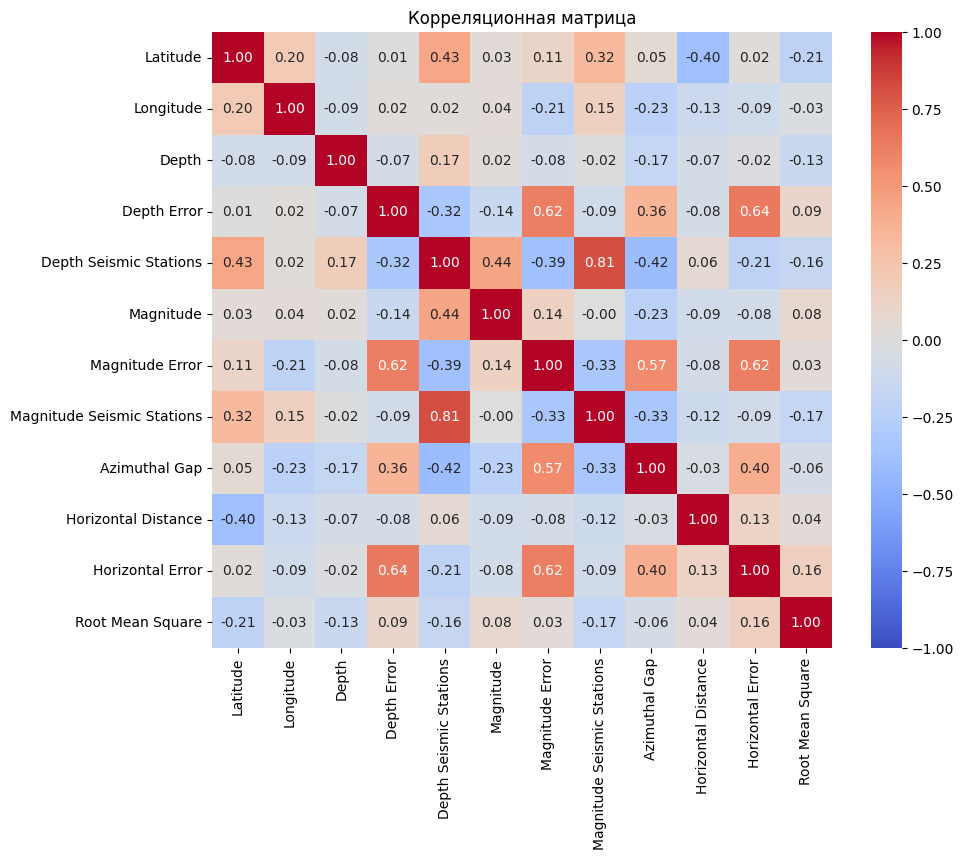

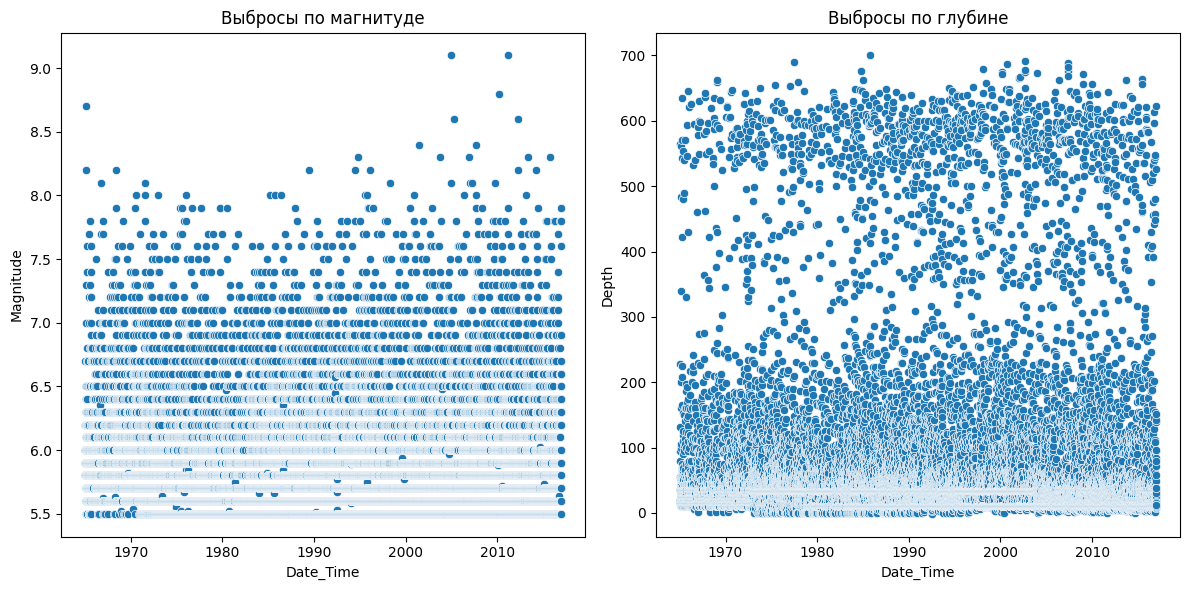

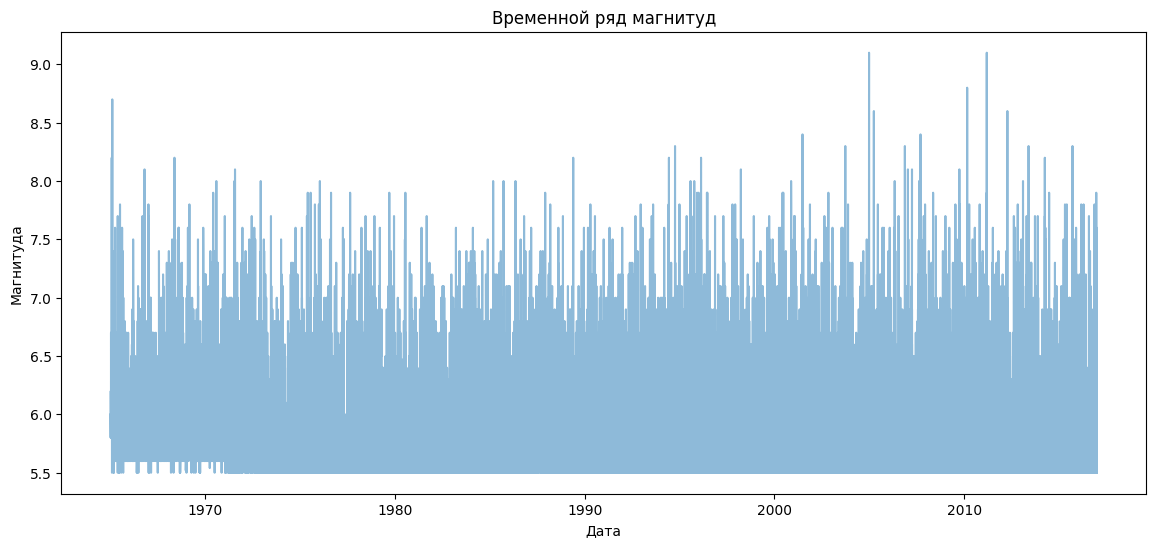

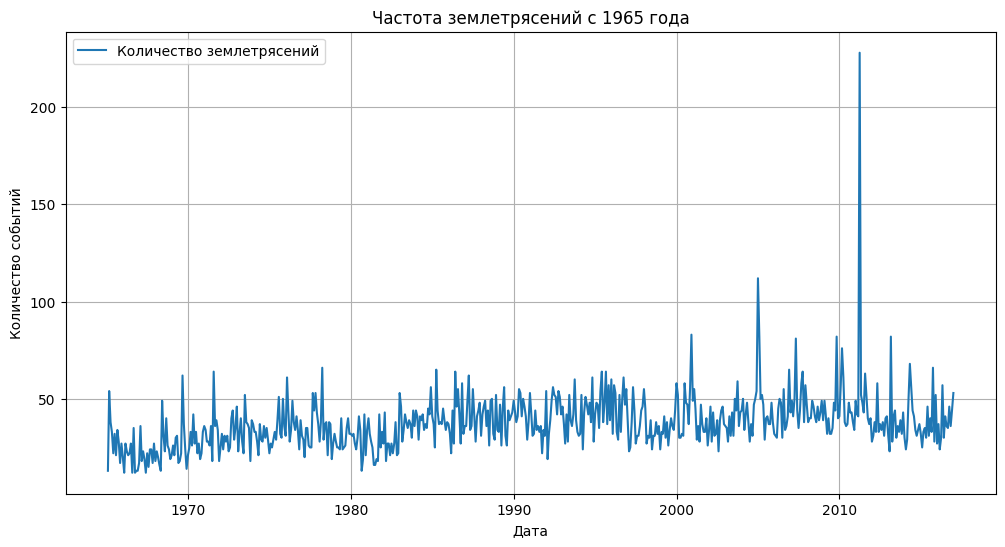

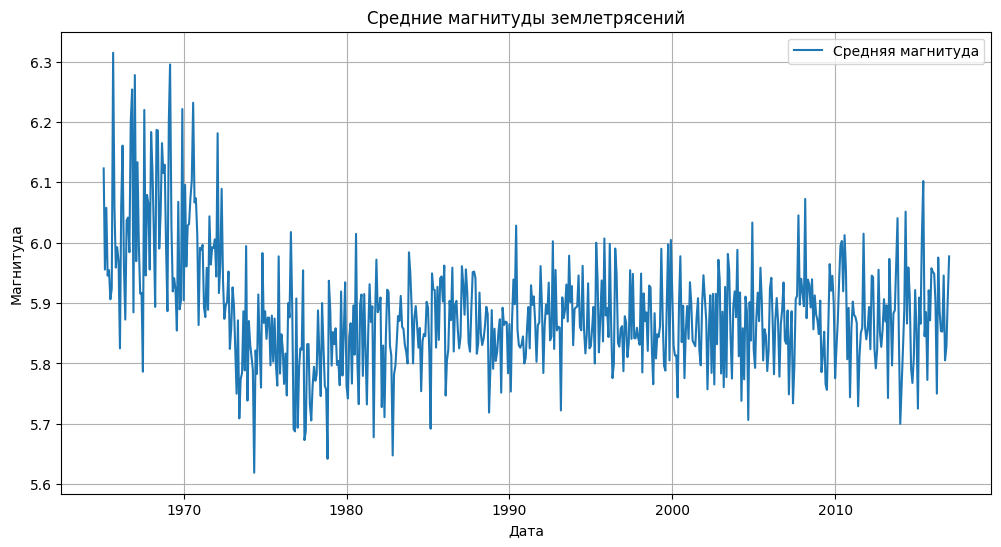

/tmp/ipykernel_2558/2259158697.py:72: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_seasonal = df.resample('M').agg({'Magnitude': 'mean'}).groupby(lambda x: x.month).mean()


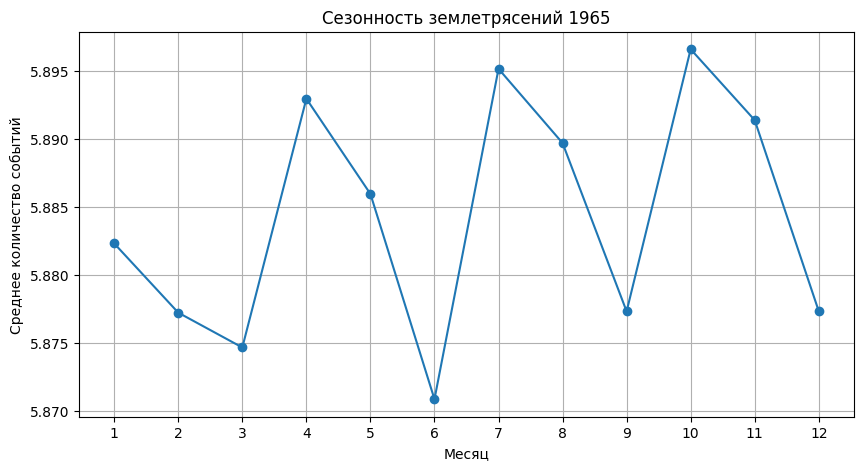

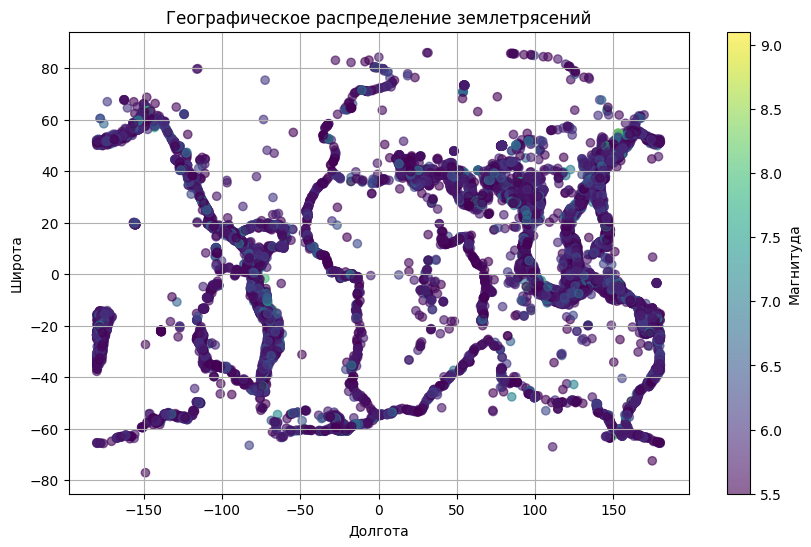

Статистика ADF (средняя магнитуда): -2.377082671397822
p-значение (средняя магнитуда): 0.14830939322461262
Статистика ADF (дифференцированный, средняя магнитуда): -10.362094484702443
p-значение (дифференцированный, средняя магнитуда): 2.3818353457035142e-18


<Figure size 1200x600 with 0 Axes>

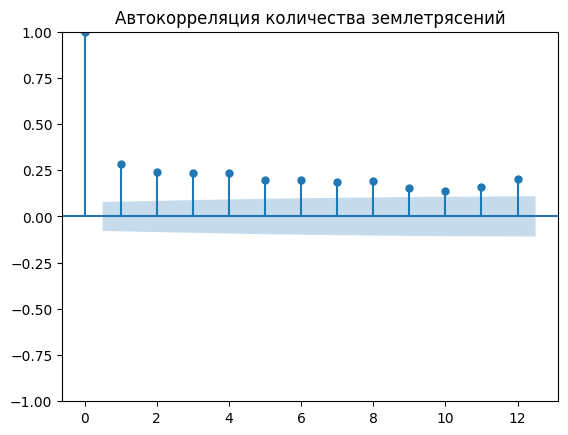

<Figure size 1200x600 with 0 Axes>

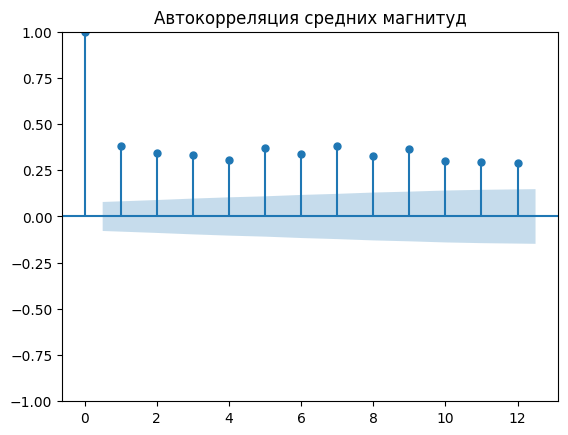

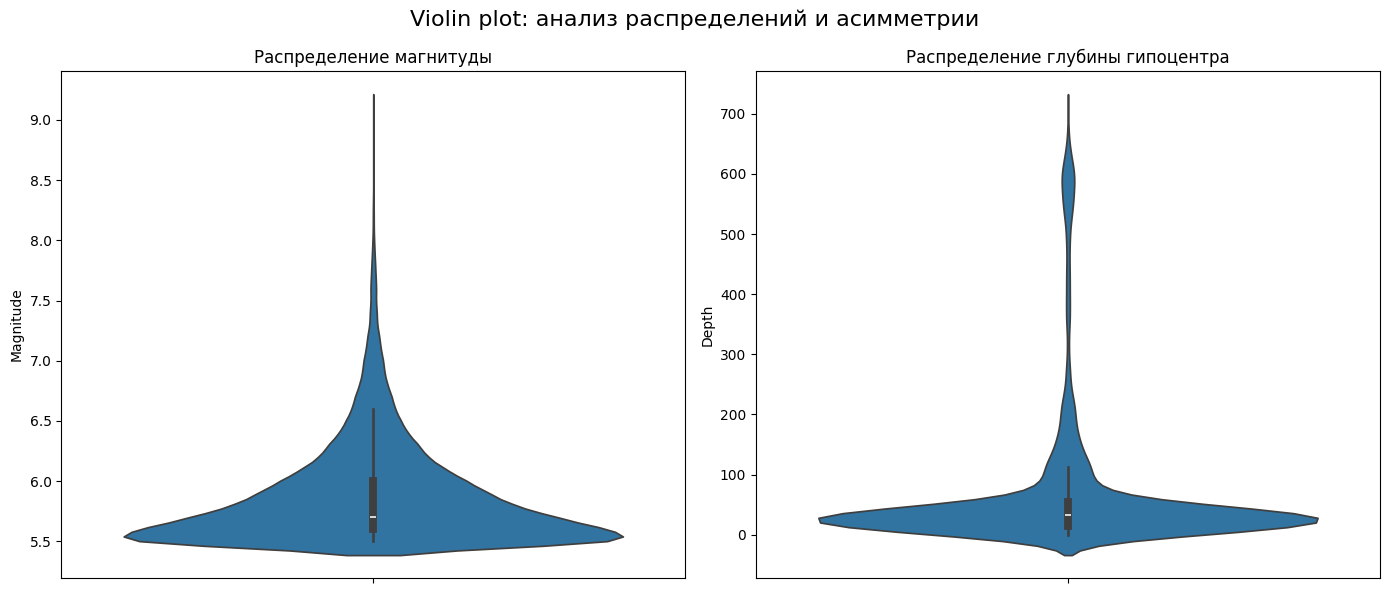

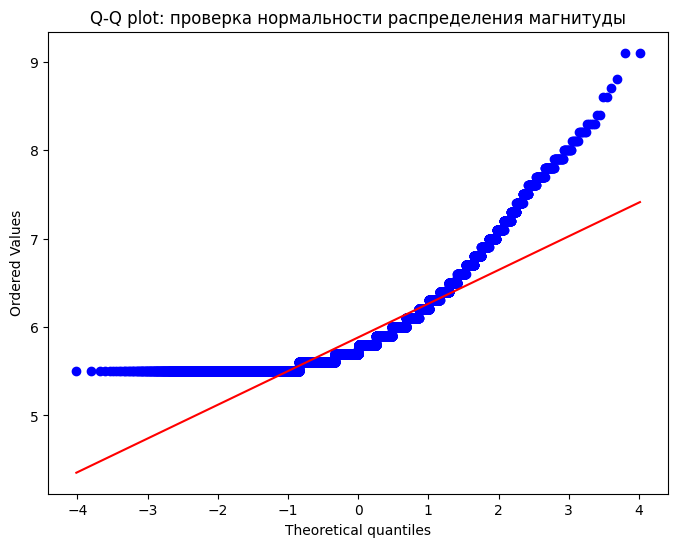

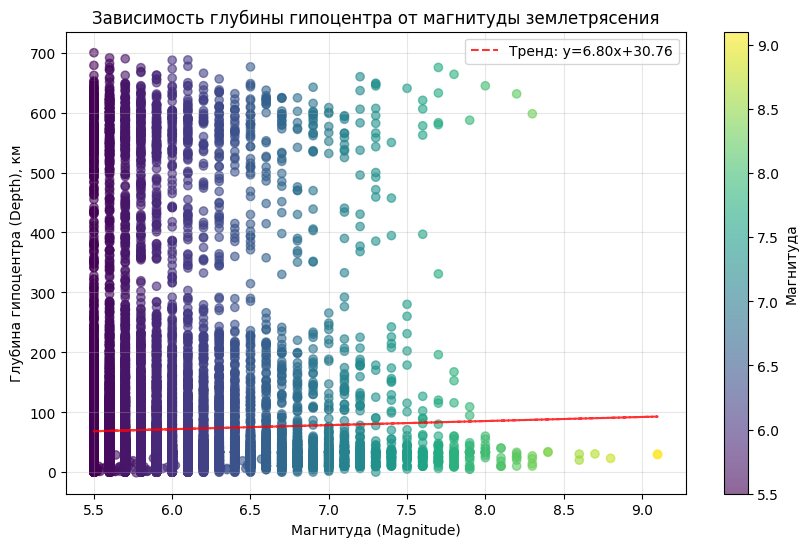

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from eda import perform_eda
from data_loader import load_and_preprocess_data
from data_description import print_dataset_description
from visualization import (
    plot_earthquake_frequency,
    plot_average_magnitude,
    plot_seasonality,
    plot_spatial_distribution
)
from stationarity_analysis import analyze_stationarity, plot_autocorrelation
from utils import print_model_metrics
from hypotheses import EDAHypotheses, MLModelHypotheses

def main():
    # Загружаем данные
    df = pd.read_csv('database.csv')
    # Описание датасета
    print_dataset_description(df)

    # Загрузка и предобработка данных
    df = load_and_preprocess_data('database.csv')

    # Устанавливаем DatetimeIndex
    if 'Date_Time' in df.columns:
        df['Date_Time'] = pd.to_datetime(df['Date_Time'])
        df = df.set_index('Date_Time')  # Устанавливаем DatetimeIndex
    else:
        raise ValueError("В данных отсутствует колонка 'Date_Time'")

    # Создаём df_magnitude здесь, чтобы она была доступна
    df_magnitude = df.resample('ME').agg({'Magnitude': 'mean'})

    # Проверка на пропущенные значения
    print("Пропущенные значения:", df.isnull().sum())

    # Создаем объекты с гипотезами
    eda_hypotheses = EDAHypotheses()
    ml_hypotheses = MLModelHypotheses()

    # Добавляем проверку гипотез в EDA
    print("\nПроверка гипотез EDA:")
    for hypothesis_name, hypothesis in eda_hypotheses.__dict__.items():
        print(f"\nГипотеза: {hypothesis['description']}")
        # Здесь добавляем код проверки метрик и тестов

    # Добавляем проверку гипотез ML моделей
    print("\nПроверка гипотез ML моделей:")
    for model_name, hypotheses in ml_hypotheses.__dict__.items():
        print(f"\nМодель: {model_name.upper()}")
        for hypothesis_name, hypothesis_description in hypotheses.items():
            print(f"- Гипотеза: {hypothesis_description}")
            # Здесь добавляем код проверки гипотез для каждой модели

    # Выполняем EDA на очищенных данных
    perform_eda(df)

    # Анализ частоты землетрясений
    df_monthly = df.resample('ME').size()
    plot_earthquake_frequency(df_monthly)

    # Анализ средних магнитуд
    df_magnitude = df.resample('ME').agg({'Magnitude': 'mean'})
    plot_average_magnitude(df_magnitude)

    # Группируем по месяцу и считаем среднюю магнитуду
    df_seasonal = df.resample('M').agg({'Magnitude': 'mean'}).groupby(lambda x: x.month).mean()
    plot_seasonality(df_seasonal)

    # Анализ пространственного распределения
    plot_spatial_distribution(df)

    # Анализ стационарности
    analyze_stationarity(df_magnitude['Magnitude'], "средняя магнитуда")

    # Анализ автокорреляции
    plot_autocorrelation(df_monthly, lags=12, title='Автокорреляция количества землетрясений')
    plot_autocorrelation(df_magnitude['Magnitude'], lags=12, title='Автокорреляция средних магнитуд')

    # 1. Violin plot для Magnitude и Depth (без дублирования boxplot)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle('Violin plot: анализ распределений и асимметрии', fontsize=16)

    sns.violinplot(data=df, y='Magnitude', ax=axes[0])
    axes[0].set_title('Распределение магнитуды')

    sns.violinplot(data=df, y='Depth', ax=axes[1])
    axes[1].set_title('Распределение глубины гипоцентра')

    plt.tight_layout()
    plt.show()

    # 2. Q‑Q plot для проверки нормальности Magnitude
    fig, ax = plt.subplots(figsize=(8, 6))
    stats.probplot(df['Magnitude'].dropna(), dist="norm", plot=ax)
    ax.set_title('Q‑Q plot: проверка нормальности распределения магнитуды')
    plt.show()

    # 3. График зависимости Depth от Magnitude
    fig, ax = plt.subplots(figsize=(10, 6))
    scatter = ax.scatter(df['Magnitude'], df['Depth'], alpha=0.6, c=df['Magnitude'], cmap='viridis')
    ax.set_xlabel('Магнитуда (Magnitude)')
    ax.set_ylabel('Глубина гипоцентра (Depth), км')
    ax.set_title('Зависимость глубины гипоцентра от магнитуды землетрясения')
    plt.colorbar(scatter, label='Магнитуда')
    z = np.polyfit(df['Magnitude'].dropna(), df['Depth'].dropna(), 1)
    p = np.poly1d(z)
    ax.plot(df['Magnitude'], p(df['Magnitude']), "r--", alpha=0.8, label=f'Тренд: y={z[0]:.2f}x+{z[1]:.2f}')
    ax.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

if __name__ == '__main__':
    main()

In [10]:
# ИНИЦИАЛИЗИРУЕМ ГЛОБАЛЬНЫЙ СЛОВАРЬ ОДИН РАЗ В НАЧАЛЕ ПРОЕКТА
if 'global_metrics' not in globals():
    global_metrics = {}
    print("Глобальный словарь global_metrics инициализирован")
else:
    print("global_metrics уже существует, содержит", len(global_metrics), "моделей")

global_metrics уже существует, содержит 1 моделей


In [38]:
import pandas as pd

# Проверяем, что словарь существует и не пуст
if 'global_metrics' in globals() and global_metrics:
    # Создаём DataFrame из глобального словаря
    df_metrics = pd.DataFrame.from_dict(global_metrics, orient='index')
    df_metrics.index.name = 'Model'

    # Сохраняем в CSV-файл
    df_metrics.to_csv('model_metricsGL.csv', index=True)
    print("✅ Метрики успешно сохранены в файл 'model_metricsGL.csv'")
    print("\nСодержимое файла:")
    print(df_metrics)
else:
    print("❌ global_metrics не найден или пуст. Проверьте выполнение моделей.")

✅ Метрики успешно сохранены в файл 'model_metricsGL.csv'

Содержимое файла:
                  MSE      RMSE       MAE        R2
Model                                              
CNN          0.044409  0.210735  0.120098  0.691696
Автоэнкодер  0.025956  0.161109  0.075743  0.819804
Трансформер  0.016959  0.130225  0.042459  0.882267
GRU          0.016374  0.127962  0.028457  0.886324
LSTM         0.016384  0.127998  0.027474  0.886260


Количество дубликатов во временном индексе: 19
Обучение модели LSTM...
Epoch 1/3
11394/11394 ━━━━━━━━━━━━━━━━━━━━ 271s 23ms/step - loss: 0.0017 - val_loss: 0.0016
Epoch 2/3
11394/11394 ━━━━━━━━━━━━━━━━━━━━ 321s 23ms/step - loss: 0.0016 - val_loss: 0.0016
Epoch 3/3
11394/11394 ━━━━━━━━━━━━━━━━━━━━ 318s 23ms/step - loss: 0.0016 - val_loss: 0.0016
2848/2848 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step


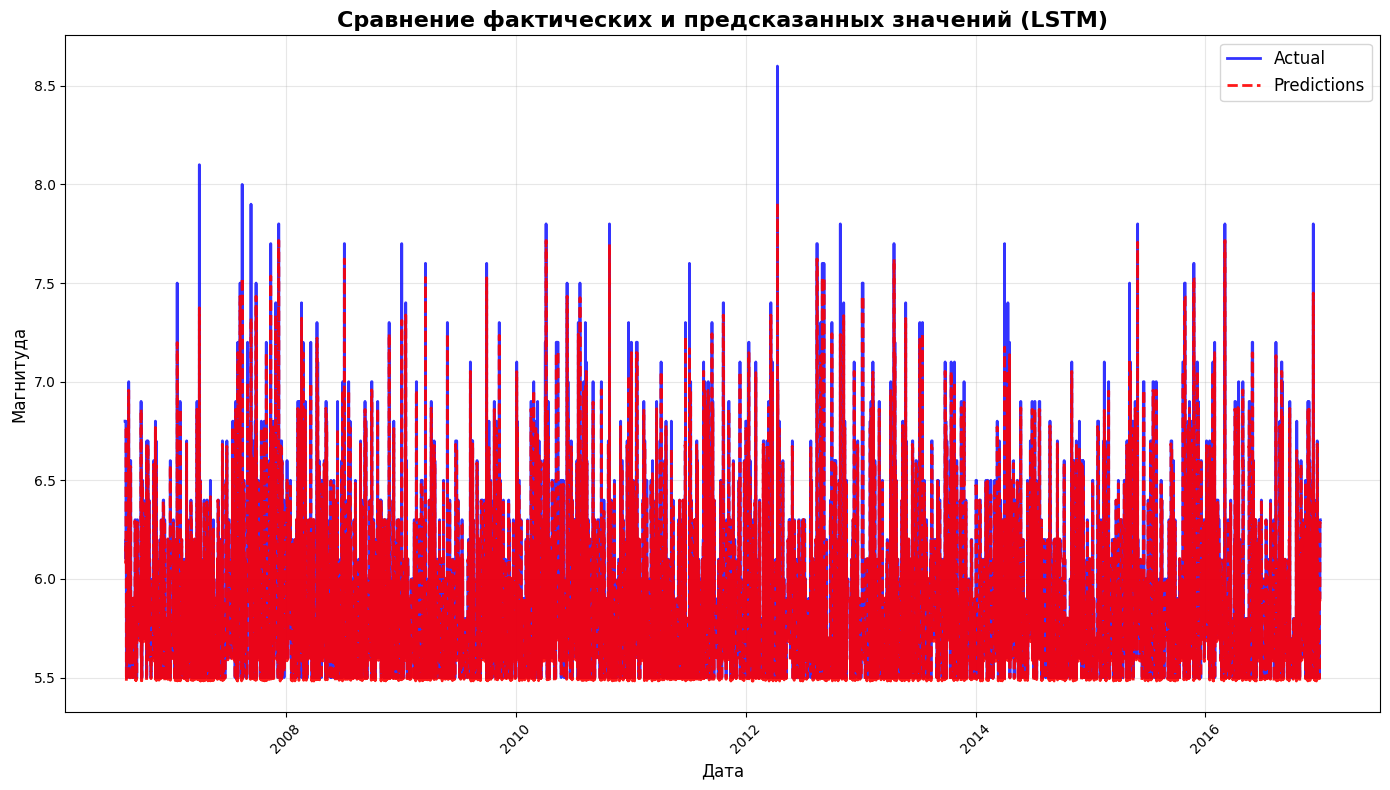

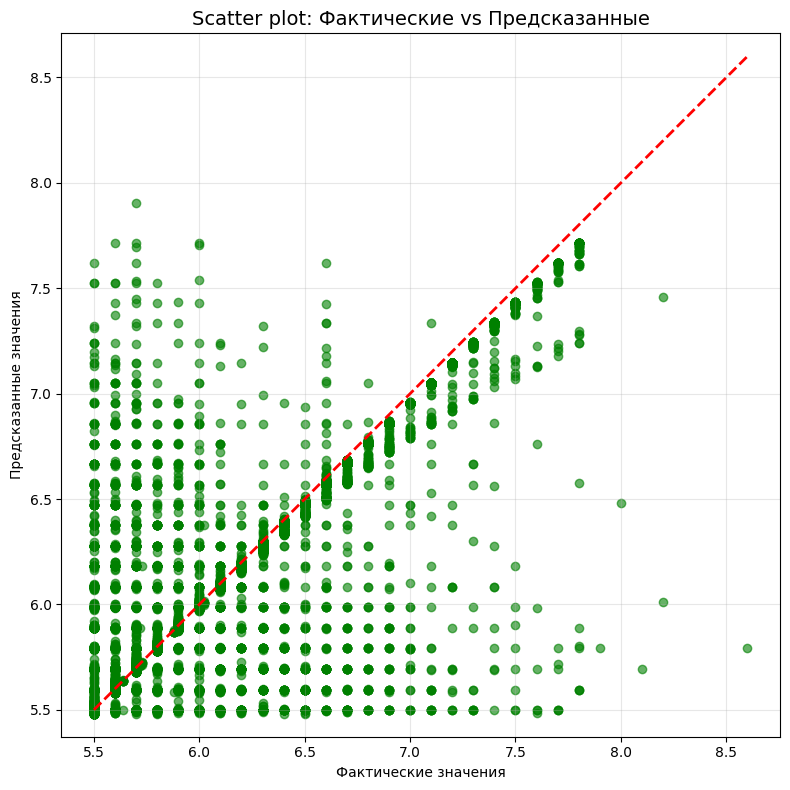

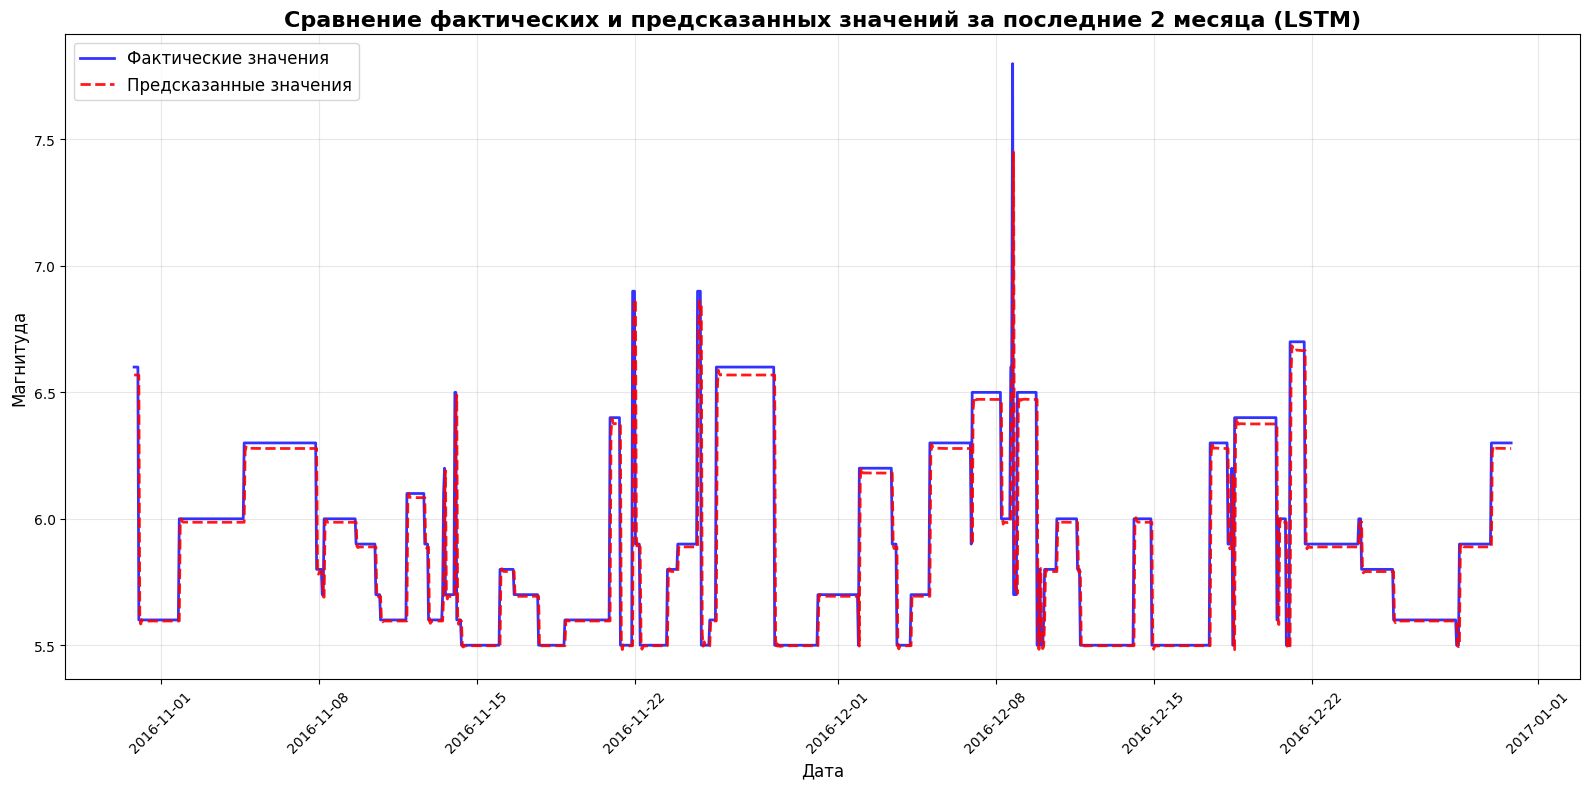


МЕТРИКИ КАЧЕСТВА МОДЕЛИ
Mean Squared Error (MSE):           0.0164
Root Mean Squared Error (RMSE):     0.1280
Mean Absolute Error (MAE):          0.0317
Mean Absolute Percentage Error (MAPE): 0.52%
Коэффициент детерминации (R²):       0.8862

--------------------------------------------------
СТАТИСТИКА ОШИБОК
--------------------------------------------------
Средняя ошибка:                    0.0111
Стандартное отклонение ошибок:       0.1276
Минимальная ошибка:               -2.2050
Максимальная ошибка:               2.8088


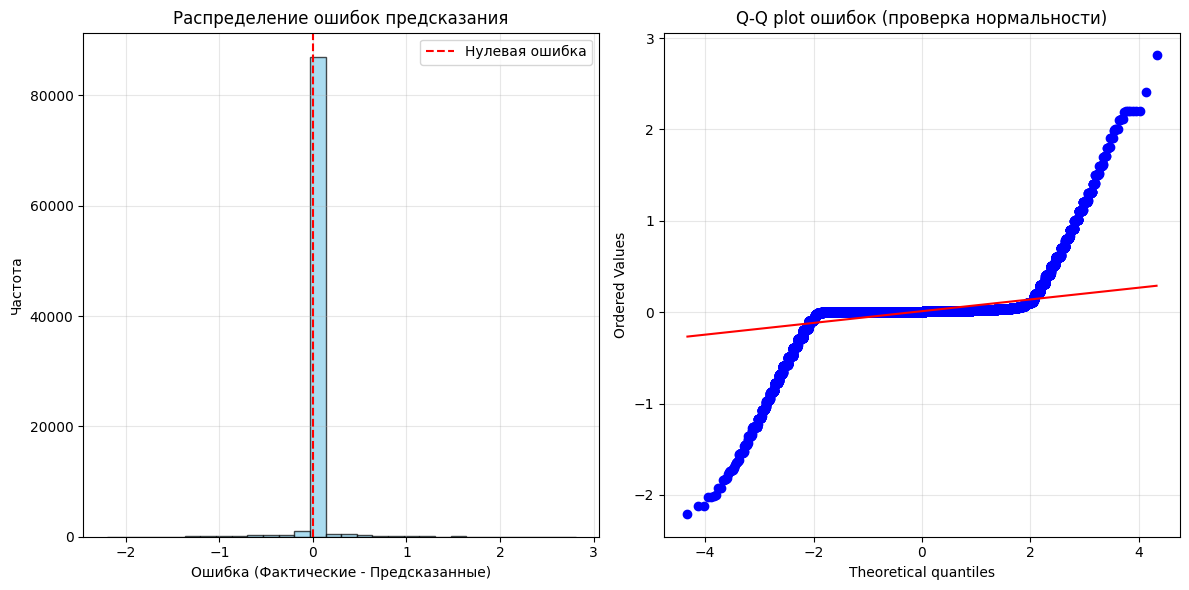

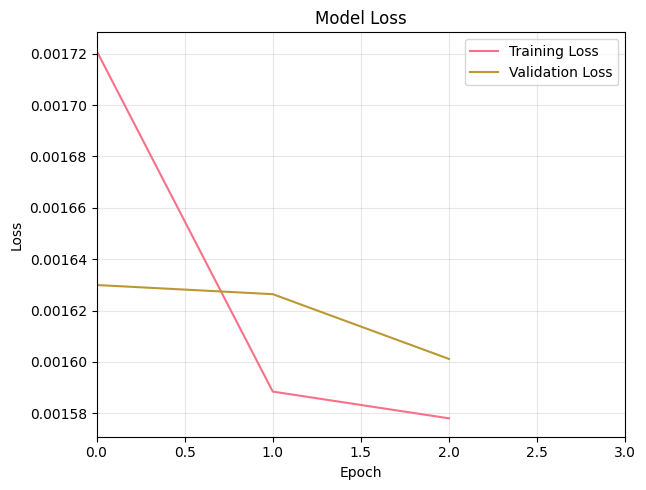


АНАЛИЗ РЕЗУЛЬТАТОВ:
🟡 Хорошая модель: приемлемая объяснённая дисперсия (0.7 ≤ R² < 0.9)
✅ Высокая точность: MAPE < 10%

Метрики сохранены в файл 'model_metricsLSTM.csv'


In [40]:
#LSTM
# Импортируем необходимые библиотеки
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from math import sqrt
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')


# Загружаем данные
data = pd.read_csv('database.csv')

# Объединяем колонки Date и Time и преобразуем в datetime
data['Date_Time'] = pd.to_datetime(data['Date'] + ' ' + data['Time'])

# Удаляем исходные колонки, если они больше не нужны
data.drop(['Date', 'Time'], axis=1, inplace=True)

# Сортируем данные по времени
data = data.sort_values('Date_Time')

# Создаём временной ряд на основе магнитуды землетрясений
ts = data.set_index('Date_Time')['Magnitude']

# Проверяем наличие дубликатов во временном индексе
print(f"Количество дубликатов во временном индексе: {ts.index.duplicated().sum()}")

# Устраняем дубликаты: агрегируем по среднему значению для одинаковых временных меток
ts = ts.groupby(ts.index).mean()

# Устанавливаем частоту временного ряда (используем строчную 'h')
ts = ts.asfreq('h', method='pad')  # method='pad' заполняет пропуски предыдущим значением

# Разделяем данные на обучающую и тестовую выборки (по дате)
split_date = ts.index[int(len(ts) * 0.8)]
train = ts[ts.index <= split_date]
test = ts[ts.index > split_date]

# Нормализация данных
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train.values.reshape(-1, 1))
test_scaled = scaler.transform(test.values.reshape(-1, 1))

# Функция для создания последовательностей
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

# Параметры
sequence_length = 24  # Используем 24 предыдущих значения для прогноза

# Создаём последовательности для обучающей выборки
X_train, y_train = create_sequences(train_scaled, sequence_length)

# Создаём последовательности для тестовой выборки
X_test, y_test = create_sequences(test_scaled, sequence_length)

# Изменяем форму данных для LSTM [samples, time steps, features]
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# Создаём модель LSTM
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(sequence_length, 1)),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(25),
    Dense(1)
])

# Компилируем модель
model.compile(optimizer='adam', loss='mean_squared_error')

# Обучаем модель
print("Обучение модели LSTM...")
history = model.fit(
    X_train,
    y_train,
    epochs=3,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

# Делаем прогноз
predictions_scaled = model.predict(X_test)

# Обратное преобразование прогноза в исходные единицы
predictions = scaler.inverse_transform(predictions_scaled)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))
# Берём последние N точек для лучшей визуализации
test_dates = test.index[sequence_length:]

# ВАРИАНТ 1: Основной график с улучшенной визуализацией
plt.figure(figsize=(14, 8))
plt.plot(test_dates, y_test_actual, label='Actual', color='blue', alpha=0.8, linewidth=2)
plt.plot(test_dates, predictions, label='Predictions', color='red', alpha=0.9, linewidth=2, linestyle='--')
plt.title('Сравнение фактических и предсказанных значений (LSTM)', fontsize=16, fontweight='bold')
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Магнитуда', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ВАРИАНТ 5: Scatter plot для анализа корреляции
plt.figure(figsize=(8, 8))
plt.scatter(y_test_actual, predictions, alpha=0.6, color='green')
plt.plot([y_test_actual.min(), y_test_actual.max()], [y_test_actual.min(), y_test_actual.max()], 'r--', lw=2)
plt.xlabel('Фактические значения')
plt.ylabel('Предсказанные значения')
plt.title('Scatter plot: Фактические vs Предсказанные', fontsize=14)
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.tight_layout()
plt.show()


# Определяем дату, отстоящую на 2 месяца назад от последней даты в тестовой выборке
last_date = test_dates[-1]
two_months_ago = last_date - pd.DateOffset(months=2)

# Фильтруем тестовые даты и соответствующие им фактические и предсказанные значения
mask = test_dates >= two_months_ago
filtered_test_dates = test_dates[mask]
filtered_y_test_actual = y_test_actual[mask]
filtered_predictions = predictions[mask]

# График: сравнение фактических и предсказанных значений за последние 2 месяца
plt.figure(figsize=(16, 8))
plt.plot(filtered_test_dates, filtered_y_test_actual,
         label='Фактические значения', color='blue', alpha=0.8, linewidth=2)
plt.plot(filtered_test_dates, filtered_predictions,
         label='Предсказанные значения', color='red', alpha=0.9, linewidth=2, linestyle='--')
plt.title('Сравнение фактических и предсказанных значений за последние 2 месяца (LSTM)',
          fontsize=16, fontweight='bold')
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Магнитуда', fontsize=12)
plt.legend(fontsize=12, loc='upper left')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Расчёт метрик качества
mse = mean_squared_error(y_test_actual, predictions)
rmse = sqrt(mse)
mae = mean_absolute_error(y_test_actual, predictions)
r2 = r2_score(y_test_actual, predictions)

# Сохраняем метрики в глобальный словарь
global_metrics['LSTM'] = {
    'MSE': mse,
    'RMSE': rmse,
    'MAE': mae,
    'R2': r2
}


# Дополнительная метрика: средняя абсолютная процентная ошибка (MAPE)
def mean_absolute_percentage_error(y_true, y_pred):
    # Избегаем деления на ноль: добавляем малое значение к знаменателю
    epsilon = 1e-15
    return np.mean(np.abs((y_true - y_pred) / (y_true + epsilon))) * 100

mape = mean_absolute_percentage_error(y_test_actual.flatten(), predictions.flatten())

# Коэффициент детерминации (R²)
from sklearn.metrics import r2_score
r2 = r2_score(y_test_actual, predictions)

# Вывод метрик с форматированием
print("\n" + "="*50)
print("МЕТРИКИ КАЧЕСТВА МОДЕЛИ")
print("="*50)
print(f"Mean Squared Error (MSE):           {mse:.4f}")
print(f"Root Mean Squared Error (RMSE):     {rmse:.4f}")
print(f"Mean Absolute Error (MAE):          {mae:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f"Коэффициент детерминации (R²):       {r2:.4f}")

# Дополнительный анализ: статистика ошибок
errors = y_test_actual.flatten() - predictions.flatten()
print("\n" + "-"*50)
print("СТАТИСТИКА ОШИБОК")
print("-"*50)
print(f"Средняя ошибка:                    {np.mean(errors):.4f}")
print(f"Стандартное отклонение ошибок:       {np.std(errors):.4f}")
print(f"Минимальная ошибка:               {np.min(errors):.4f}")
print(f"Максимальная ошибка:               {np.max(errors):.4f}")

# Визуализация распределения ошибок
plt.figure(figsize=(12, 6))

# Гистограмма ошибок
plt.subplot(1, 2, 1)
plt.hist(errors, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
plt.axvline(x=0, color='red', linestyle='--', label='Нулевая ошибка')
plt.title('Распределение ошибок предсказания')
plt.xlabel('Ошибка (Фактические - Предсказанные)')
plt.ylabel('Частота')
plt.legend()
plt.grid(True, alpha=0.3)

# Q‑Q plot для проверки нормальности распределения ошибок
from scipy import stats
plt.subplot(1, 2, 2)
stats.probplot(errors, dist="norm", plot=plt)
plt.title('Q‑Q plot ошибок (проверка нормальности)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# БЛОК 2: График метрик качества обучения (по эпохам)
plt.figure(figsize=(12, 5))

# Первый график: Loss
plt.subplot(1, 2, 1)
if 'loss' in history.history:
    plt.plot(history.history['loss'], label='Training Loss')
else:
    print("⚠️ Предупреждение: метрика 'loss' не найдена в истории обучения")

if 'val_loss' in history.history:
    plt.plot(history.history['val_loss'], label='Validation Loss')
else:
    print("⚠️ Предупреждение: метрика 'val_loss' не найдена в истории обучения")

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 3)  # Ограничение по эпохам: 0–2 (т. е. 3 эпохи)


plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("АНАЛИЗ РЕЗУЛЬТАТОВ:")
print("="*50)

if r2 >= 0.9:
    print("✅ Отличная модель: высокая объяснённая дисперсия (R² ≥ 0.9)")
elif r2 >= 0.7:
    print("🟡 Хорошая модель: приемлемая объяснённая дисперсия (0.7 ≤ R² < 0.9)")
else:
    print("🔴 Требует улучшения: низкая объяснённая дисперсия (R² < 0.7)")

if mape < 10:
    print("✅ Высокая точность: MAPE < 10%")
elif mape < 20:
    print("🟡 Удовлетворительная точность: 10% ≤ MAPE < 20%")
else:
    print("🔴 Низкая точность: MAPE ≥ 20%")

 # Сводная таблица всех метрик
#print("\nСВОДНАЯ ТАБЛИЦА МЕТРИК:")
metrics_df = pd.DataFrame(global_metrics).T
#print(metrics_df.round(4).to_string())

# Сохранение метрик в файл (опционально)
try:
    metrics_df.to_csv('model_metricsLSTM.csv')
    print("\nМетрики сохранены в файл 'model_metricsLSTM.csv'")
except Exception as e:
    print(f"\nНе удалось сохранить метрики в файл: {e}")

Количество дубликатов во временном индексе: 19
Обучение модели GRU...
Epoch 1/5
11394/11394 ━━━━━━━━━━━━━━━━━━━━ 292s 25ms/step - loss: 0.0017 - val_loss: 0.0016
Epoch 2/5
11394/11394 ━━━━━━━━━━━━━━━━━━━━ 320s 25ms/step - loss: 0.0016 - val_loss: 0.0016
Epoch 3/5
11394/11394 ━━━━━━━━━━━━━━━━━━━━ 327s 26ms/step - loss: 0.0016 - val_loss: 0.0016
Epoch 4/5
11394/11394 ━━━━━━━━━━━━━━━━━━━━ 283s 25ms/step - loss: 0.0016 - val_loss: 0.0016
Epoch 5/5
11394/11394 ━━━━━━━━━━━━━━━━━━━━ 295s 26ms/step - loss: 0.0016 - val_loss: 0.0016
2848/2848 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step


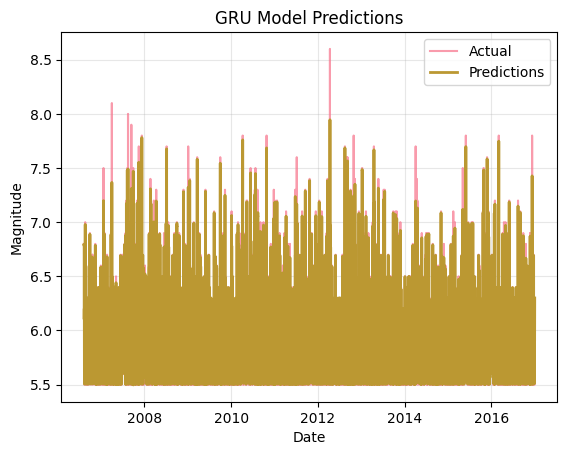

Mean Squared Error: 0.02
Root Mean Squared Error: 0.13
Mean Absolute Error: 0.03


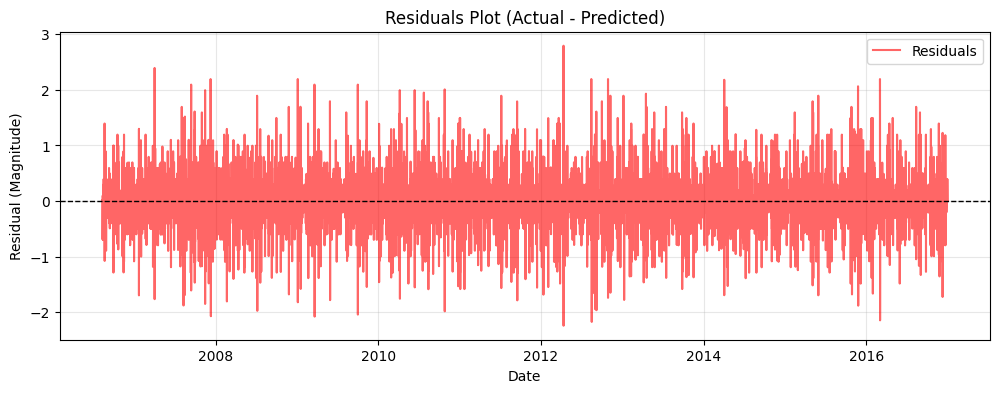

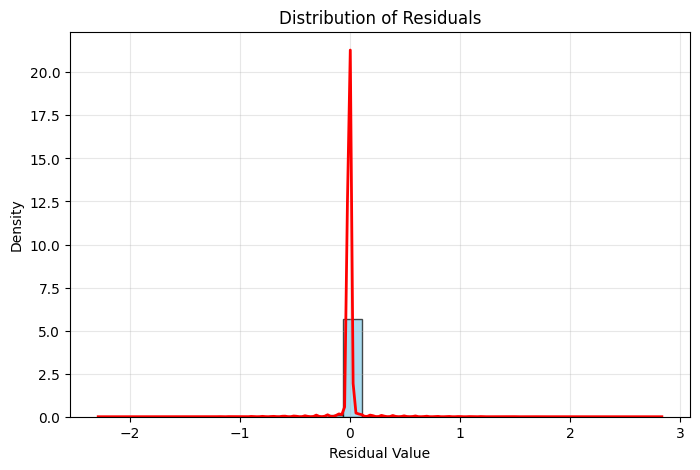

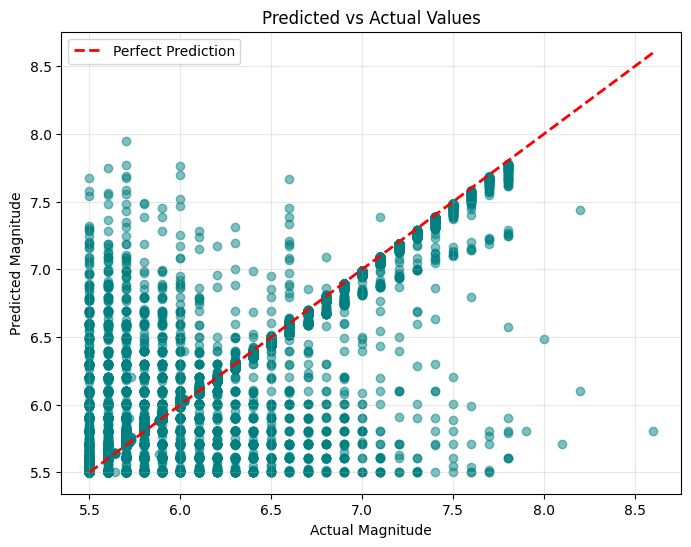

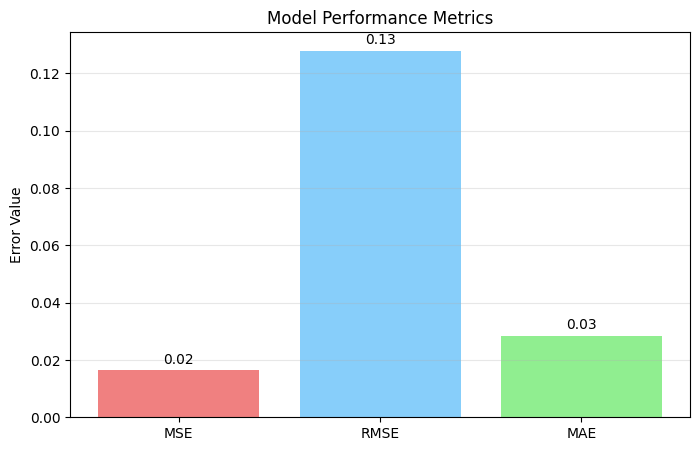

Mean Squared Error: 0.02
Root Mean Squared Error: 0.13
Mean Absolute Error: 0.03

Calculating feature importance via permutation...
2848/2848 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step
2848/2848 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step
2848/2848 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step
2848/2848 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step
2848/2848 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step
2848/2848 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step
2848/2848 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step
2848/2848 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step
2848/2848 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step
2848/2848 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step
2848/2848 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step
2848/2848 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step
2848/2848 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step
2848/2848 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step
2848/2848 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step
2848/2848 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step
2848/2848 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step
2848/2848 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step
2848/2848 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step
2848/2848 ━━━━━━━━━━━━━━━━━━━━ 1

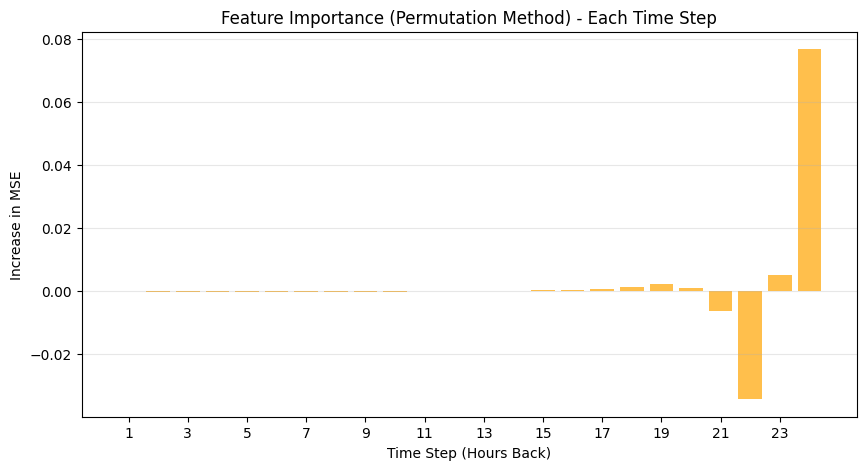

Feature importance scores (increase in MSE when shuffled):
  Time step 1: -0.0000
  Time step 2: -0.0001
  Time step 3: -0.0001
  Time step 4: -0.0001
  Time step 5: -0.0001
  Time step 6: -0.0001
  Time step 7: -0.0001
  Time step 8: -0.0001
  Time step 9: -0.0001
  Time step 10: -0.0001
  Time step 11: -0.0000
  Time step 12: 0.0000
  Time step 13: 0.0001
  Time step 14: 0.0002
  Time step 15: 0.0003
  Time step 16: 0.0005
  Time step 17: 0.0008
  Time step 18: 0.0014
  Time step 19: 0.0022
  Time step 20: 0.0010
  Time step 21: -0.0062
  Time step 22: -0.0343
  Time step 23: 0.0053
  Time step 24: 0.0768

Метрики сохранены в файл 'model_metricsGRU.csv'


In [26]:
#GRU
# Импортируем необходимые библиотеки
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from math import sqrt
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout  # ИЗМЕНЕНО: импортируем GRU вместо LSTM
import warnings
warnings.filterwarnings('ignore')


# Загружаем данные
data = pd.read_csv('database.csv')

# Объединяем колонки Date и Time и преобразуем в datetime
data['Date_Time'] = pd.to_datetime(data['Date'] + ' ' + data['Time'])

# Удаляем исходные колонки, если они больше не нужны
data.drop(['Date', 'Time'], axis=1, inplace=True)

# Сортируем данные по времени
data = data.sort_values('Date_Time')

# Создаём временной ряд на основе магнитуды землетрясений
ts = data.set_index('Date_Time')['Magnitude']

# Проверяем наличие дубликатов во временном индексе
print(f"Количество дубликатов во временном индексе: {ts.index.duplicated().sum()}")

# Устраняем дубликаты: агрегируем по среднему значению для одинаковых временных меток
ts = ts.groupby(ts.index).mean()

# Устанавливаем частоту временного ряда (используем строчную 'h')
ts = ts.asfreq('h', method='pad')  # method='pad' заполняет пропуски предыдущим значением

# Разделяем данные на обучающую и тестовую выборки (по дате)
split_date = ts.index[int(len(ts) * 0.8)]
train = ts[ts.index <= split_date]
test = ts[ts.index > split_date]

# Нормализация данных
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train.values.reshape(-1, 1))
test_scaled = scaler.transform(test.values.reshape(-1, 1))

# Функция для создания последовательностей
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

# Параметры
sequence_length = 24  # Используем 24 предыдущих значения для прогноза

# Создаём последовательности для обучающей выборки
X_train, y_train = create_sequences(train_scaled, sequence_length)

# Создаём последовательности для тестовой выборки
X_test, y_test = create_sequences(test_scaled, sequence_length)

# Изменяем форму данных для GRU [samples, time steps, features]
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# Создаём модель GRU — ИЗМЕНЕНО: GRU вместо LSTM
model = Sequential([
    GRU(50, return_sequences=True, input_shape=(sequence_length, 1)),  # ИЗМЕНЕНО: GRU слой
    Dropout(0.2),
    GRU(50, return_sequences=False),  # ИЗМЕНЕНО: GRU слой
    Dropout(0.2),
    Dense(25),
    Dense(1)
])

# Компилируем модель
model.compile(optimizer='adam', loss='mean_squared_error')

# Обучаем модель
print("Обучение модели GRU...")  # ИЗМЕНЕНО: сообщение об обучении GRU
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

# Делаем прогноз
predictions_scaled = model.predict(X_test)

# Обратное преобразование прогноза в исходные единицы
predictions = scaler.inverse_transform(predictions_scaled)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))
# Берём последние N точек для лучшей визуализации
test_dates = test.index[sequence_length:]

plt.plot(test_dates, y_test_actual, label='Actual', alpha=0.7)
plt.plot(test_dates, predictions, label='Predictions', linewidth=2)
plt.title('GRU Model Predictions')  # ИЗМЕНЕНО: заголовок графика для GRU
plt.xlabel('Date')
plt.ylabel('Magnitude')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Расчёт метрик качества
mse = mean_squared_error(y_test_actual, predictions)
rmse = sqrt(mse)
mae = mean_absolute_error(y_test_actual, predictions)
r2 = r2_score(y_test_actual, predictions)

# Сохраняем метрики в глобальный словарь
global_metrics['GRU'] = {
    'MSE': mse,
    'RMSE': rmse,
    'MAE': mae,
    'R2': r2
}

print(f"Mean Squared Error: {mse:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"Mean Absolute Error: {mae:.2f}")

# 1. График остатков (фактические значения минус предсказания)
residuals = y_test_actual.flatten() - predictions.flatten()

plt.figure(figsize=(12, 4))
plt.plot(test_dates, residuals, color='red', alpha=0.6, label='Residuals')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.title('Residuals Plot (Actual - Predicted)')
plt.xlabel('Date')
plt.ylabel('Residual (Magnitude)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 2. График распределения остатков (гистограмма + KDE)
plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=30, density=True, alpha=0.7, color='skyblue', edgecolor='black')
plt.title('Distribution of Residuals')
plt.xlabel('Residual Value')
plt.ylabel('Density')
# Добавляем линию KDE (если есть seaborn)
try:
    import seaborn as sns
    sns.kdeplot(residuals, color="red", linewidth=2)
except ImportError:
    pass
plt.grid(True, alpha=0.3)
plt.show()

# 3. Scatter plot: Предсказанные vs Фактические значения
plt.figure(figsize=(8, 6))
plt.scatter(y_test_actual, predictions, alpha=0.5, color='teal')
plt.plot([y_test_actual.min(), y_test_actual.max()], [y_test_actual.min(), y_test_actual.max()],
         'r--', lw=2, label='Perfect Prediction')
plt.title('Predicted vs Actual Values')
plt.xlabel('Actual Magnitude')
plt.ylabel('Predicted Magnitude')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 4. График метрик качества (столбчатая диаграмма)
metrics = ['MSE', 'RMSE', 'MAE']
values = [mse, rmse, mae]

plt.figure(figsize=(8, 5))
bars = plt.bar(metrics, values, color=['lightcoral', 'lightskyblue', 'lightgreen'])
plt.title('Model Performance Metrics')
plt.ylabel('Error Value')
# Подписываем значения на столбцах
for bar, value in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(values) * 0.01,
             f'{value:.2f}', ha='center', va='bottom')
plt.grid(axis='y', alpha=0.3)
plt.show()

print(f"Mean Squared Error: {mse:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"Mean Absolute Error: {mae:.2f}")

# --- ВАЖНОСТЬ ПРИЗНАКОВ (упрощённый пермутационный подход) ---

print("\nCalculating feature importance via permutation...")

def calculate_permutation_importance(model, X_test, y_test, scaler, metric_func=mean_squared_error):
    """
    Упрощённый расчёт важности признаков через пермутацию.
    Для каждого временного шага (признака) перемешивает его значения и замеряет рост ошибки.
    """
    baseline_score = metric_func(y_test, model.predict(X_test))
    importance_scores = np.zeros(X_test.shape[1])  # Количество временных шагов

    for i in range(X_test.shape[1]):
        X_permuted = X_test.copy()
        # Перемешиваем значения только для i‑го временного шага во всех выборках
        np.random.shuffle(X_permuted[:, i, :])
        permuted_predictions = model.predict(X_permuted)
        permuted_score = metric_func(y_test, permuted_predictions)
        importance_scores[i] = permuted_score - baseline_score  # Рост ошибки

    return importance_scores

# Рассчитываем важность
importance_scores = calculate_permutation_importance(
    model, X_test, y_test_actual, scaler
)

# Визуализация важности признаков
plt.figure(figsize=(10, 5))
plt.bar(range(1, len(importance_scores) + 1), importance_scores, color='orange', alpha=0.7)
plt.title('Feature Importance (Permutation Method) - Each Time Step')
plt.xlabel('Time Step (Hours Back)')
plt.ylabel('Increase in MSE')
plt.xticks(range(1, len(importance_scores) + 1, 2))  # Метки каждые 2 шага
plt.grid(axis='y', alpha=0.3)
plt.show()

print("Feature importance scores (increase in MSE when shuffled):")
for i, score in enumerate(importance_scores, 1):
    print(f"  Time step {i}: {score:.4f}")

    # Сводная таблица всех метрик
#print("\nСВОДНАЯ ТАБЛИЦА МЕТРИК:")
metrics_df = pd.DataFrame(global_metrics).T
#print(metrics_df.round(4).to_string())

# Сохранение метрик в файл (опционально)
try:
    metrics_df.to_csv('model_metricsGRU.csv')
    print("\nМетрики сохранены в файл 'model_metricsGRU.csv'")
except Exception as e:
    print(f"\nНе удалось сохранить метрики в файл: {e}")

Количество дубликатов во временном индексе: 19
Обучение модели Transformer...
11394/11394 ━━━━━━━━━━━━━━━━━━━━ 757s 66ms/step - loss: 0.0107 - mae: 0.0618 - val_loss: 0.0017 - val_mae: 0.0133
2848/2848 ━━━━━━━━━━━━━━━━━━━━ 48s 17ms/step


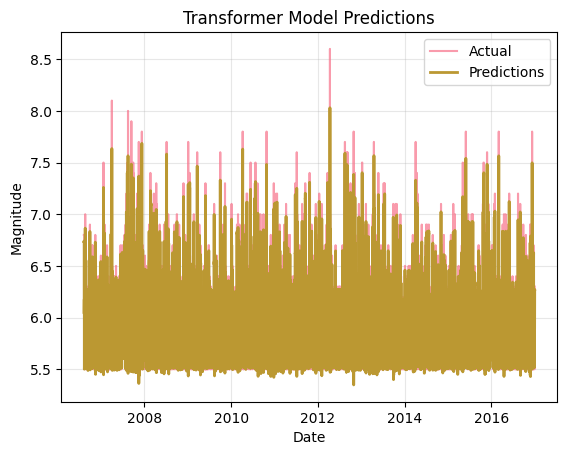

Mean Squared Error: 0.02
Root Mean Squared Error: 0.13
Mean Absolute Error: 0.04


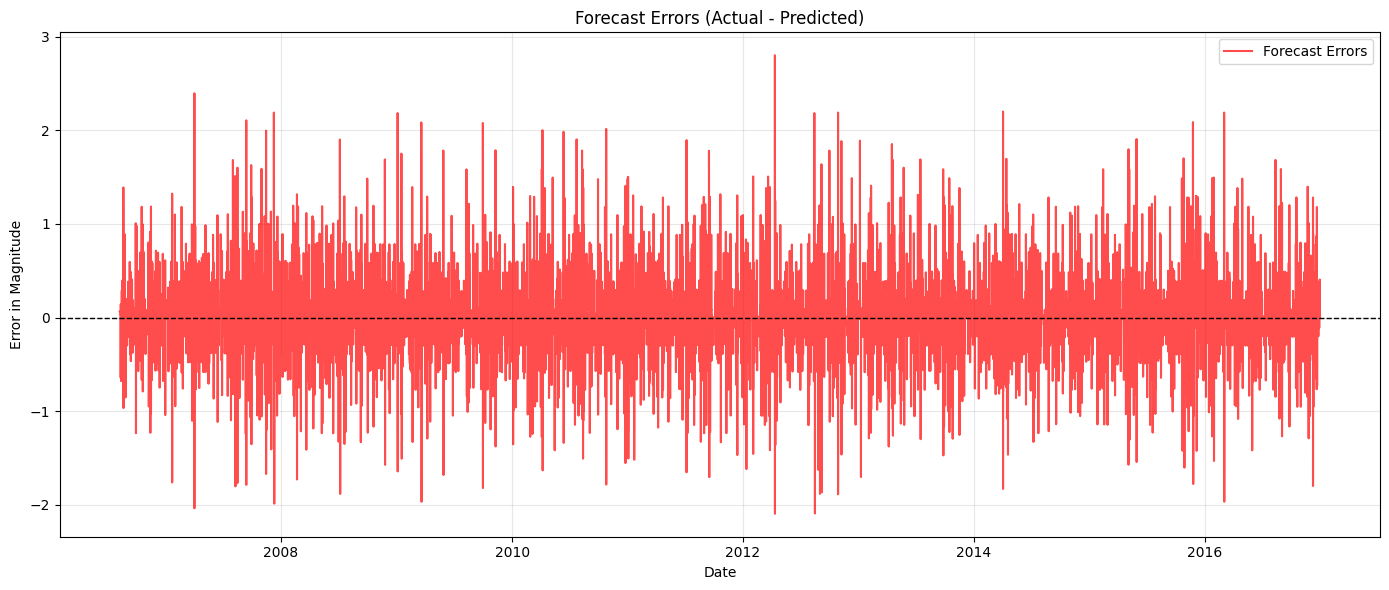

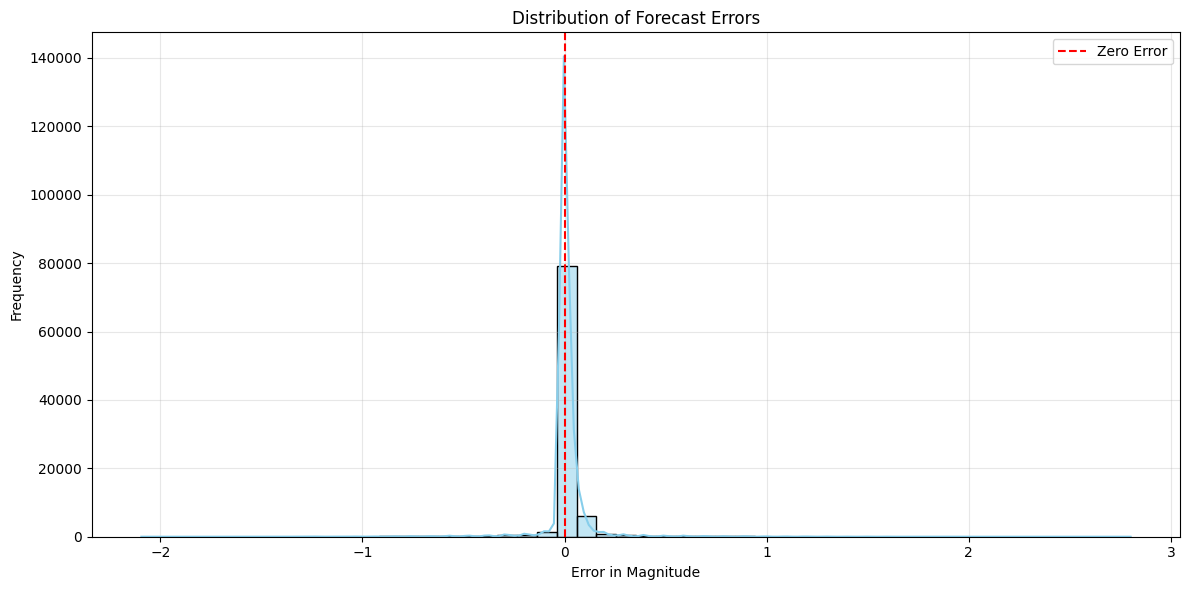

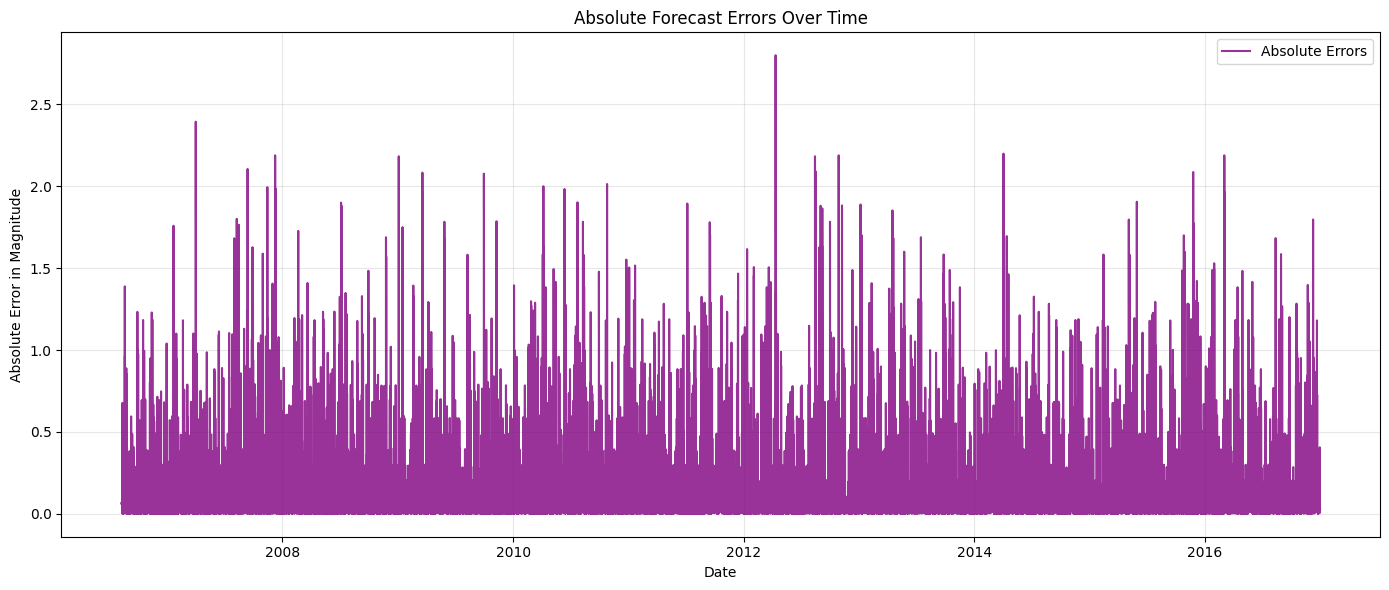


Метрики сохранены в файл 'model_metricsTR.csv'


In [25]:
#TRANSFORMER
# Импортируем необходимые библиотеки
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from math import sqrt
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, LayerNormalization
from tensorflow.keras.layers import MultiHeadAttention
from tensorflow.keras.optimizers import Adam
import tensorflow as tf
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import r2_score
import seaborn as sns



# Загружаем данные
data = pd.read_csv('database.csv')

# Объединяем колонки Date и Time и преобразуем в datetime
data['Date_Time'] = pd.to_datetime(data['Date'] + ' ' + data['Time'])

# Удаляем исходные колонки, если они больше не нужны
data.drop(['Date', 'Time'], axis=1, inplace=True)

# Сортируем данные по времени
data = data.sort_values('Date_Time')

# Создаём временной ряд на основе магнитуды землетрясений
ts = data.set_index('Date_Time')['Magnitude']

# Проверяем наличие дубликатов во временном индексе
print(f"Количество дубликатов во временном индексе: {ts.index.duplicated().sum()}")

# Устраняем дубликаты: агрегируем по среднему значению для одинаковых временных меток
ts = ts.groupby(ts.index).mean()

# Устанавливаем частоту временного ряда (используем строчную 'h')
ts = ts.asfreq('h', method='pad')  # method='pad' заполняет пропуски предыдущим значением

# Разделяем данные на обучающую и тестовую выборки (по дате)
split_date = ts.index[int(len(ts) * 0.8)]
train = ts[ts.index <= split_date]
test = ts[ts.index > split_date]

# Нормализация данных
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train.values.reshape(-1, 1))
test_scaled = scaler.transform(test.values.reshape(-1, 1))

# Функция для создания последовательностей
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

# Параметры
sequence_length = 24  # Используем 24 предыдущих значения для прогноза

# Создаём последовательности для обучающей выборки
X_train, y_train = create_sequences(train_scaled, sequence_length)

# Создаём последовательности для тестовой выборки
X_test, y_test = create_sequences(test_scaled, sequence_length)

# Изменяем форму данных для Transformer [samples, time steps, features]
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# Построитель позиционного кодирования
def positional_encoding(position, d_model):
    angle_rads = get_angles(
        np.arange(position)[:, np.newaxis],
        np.arange(d_model)[np.newaxis, :],
        d_model
    )
    # Применяем sin к чётным индексам в массиве; 2i
    angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
    # Применяем cos к нечётным индексам в массиве; 2i+1
    angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])
    pos_encoding = angle_rads[np.newaxis, ...]
    return tf.cast(pos_encoding, dtype=tf.float32)

def get_angles(pos, i, d_model):
    angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
    return pos * angle_rates

# Создаём позиционное кодирование
pos_encoding = positional_encoding(sequence_length, d_model=64)

# Архитектура Transformer
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
    # Attention и Normalization
    x = MultiHeadAttention(
        key_dim=head_size,
        num_heads=num_heads,
        dropout=dropout
    )(inputs, inputs)
    x = Dropout(dropout)(x)
    res = x + inputs
    x = LayerNormalization(epsilon=1e-6)(res)

    # Feed Forward
    x = Dense(ff_dim, activation="relu")(x)
    x = Dropout(dropout)(x)
    x = Dense(inputs.shape[-1])(x)
    x = Dropout(dropout)(x)
    return x + res

# Создаём модель Transformer
inputs = Input(shape=(sequence_length, 1))
x = Dense(64)(inputs)  # Проекция в пространство большей размерности

# Добавляем позиционное кодирование
x += pos_encoding[:, :sequence_length, :]

# Несколько блоков Transformer
for _ in range(2):  # 2 блока Transformer
    x = transformer_encoder(x, head_size=64, num_heads=4, ff_dim=128, dropout=0.2)

# Глобальное усреднение и финальный прогноз
x = tf.keras.layers.GlobalAveragePooling1D()(x)
x = Dropout(0.2)(x)
outputs = Dense(1)(x)

model = Model(inputs, outputs)

# Компилируем модель
model.compile(optimizer=Adam(learning_rate=1e-4), loss='mean_squared_error', metrics=['mae'])

# Обучаем модель
print("Обучение модели Transformer...")
history = model.fit(
    X_train,
    y_train,
    epochs=1,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

# Делаем прогноз
predictions_scaled = model.predict(X_test)

# Обратное преобразование прогноза в исходные единицы
predictions = scaler.inverse_transform(predictions_scaled)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))
# Берём последние N точек для лучшей визуализации
test_dates = test.index[sequence_length:]

plt.plot(test_dates, y_test_actual, label='Actual', alpha=0.7)
plt.plot(test_dates, predictions, label='Predictions', linewidth=2)
plt.title('Transformer Model Predictions')
plt.xlabel('Date')
plt.ylabel('Magnitude')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Расчёт метрик качества
mse = mean_squared_error(y_test_actual, predictions)
rmse = sqrt(mse)
mae = mean_absolute_error(y_test_actual, predictions)
r2 = r2_score(y_test_actual, predictions)

# Сохраняем метрики в глобальный словарь
global_metrics['Трансформер'] = {
    'MSE': mse,
    'RMSE': rmse,
    'MAE': mae,
    'R2': r2
}

print(f"Mean Squared Error: {mse:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"Mean Absolute Error: {mae:.2f}")

# 1. График ошибок прогнозирования
plt.figure(figsize=(14, 6))
errors = y_test_actual.flatten() - predictions.flatten()
plt.plot(test_dates, errors, label='Forecast Errors', color='red', alpha=0.7)
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.title('Forecast Errors (Actual - Predicted)')
plt.xlabel('Date')
plt.ylabel('Error in Magnitude')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# 3. Анализ распределения ошибок (аналог важности признаков)
plt.figure(figsize=(12, 6))
sns.histplot(errors, bins=50, kde=True, color='skyblue', edgecolor='black')
plt.axvline(x=0, color='red', linestyle='--', label='Zero Error')
plt.title('Distribution of Forecast Errors')
plt.xlabel('Error in Magnitude')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Дополнительно: график абсолютных ошибок для выявления сложных периодов
plt.figure(figsize=(14, 6))
abs_errors = np.abs(errors)
plt.plot(test_dates, abs_errors, label='Absolute Errors', color='purple', alpha=0.8)
plt.title('Absolute Forecast Errors Over Time')
plt.xlabel('Date')
plt.ylabel('Absolute Error in Magnitude')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Сводная таблица всех метрик
#print("\nСВОДНАЯ ТАБЛИЦА МЕТРИК:")
metrics_df = pd.DataFrame(global_metrics).T
#print(metrics_df.round(4).to_string())

# Сохранение метрик в файл (опционально)
try:
    metrics_df.to_csv('model_metricsTR.csv')
    print("\nМетрики сохранены в файл 'model_metricsTR.csv'")
except Exception as e:
    print(f"\nНе удалось сохранить метрики в файл: {e}")

Количество дубликатов во временном индексе: 19
Обучение модели CNN...
Epoch 1/5
11394/11394 ━━━━━━━━━━━━━━━━━━━━ 62s 5ms/step - loss: 0.0043 - mae: 0.0345 - val_loss: 0.0043 - val_mae: 0.0364
Epoch 2/5
11394/11394 ━━━━━━━━━━━━━━━━━━━━ 75s 5ms/step - loss: 0.0041 - mae: 0.0318 - val_loss: 0.0042 - val_mae: 0.0369
Epoch 3/5
11394/11394 ━━━━━━━━━━━━━━━━━━━━ 61s 5ms/step - loss: 0.0040 - mae: 0.0310 - val_loss: 0.0043 - val_mae: 0.0374
Epoch 4/5
11394/11394 ━━━━━━━━━━━━━━━━━━━━ 76s 5ms/step - loss: 0.0040 - mae: 0.0304 - val_loss: 0.0043 - val_mae: 0.0392
Epoch 5/5
11394/11394 ━━━━━━━━━━━━━━━━━━━━ 64s 6ms/step - loss: 0.0039 - mae: 0.0302 - val_loss: 0.0043 - val_mae: 0.0375
2848/2848 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step


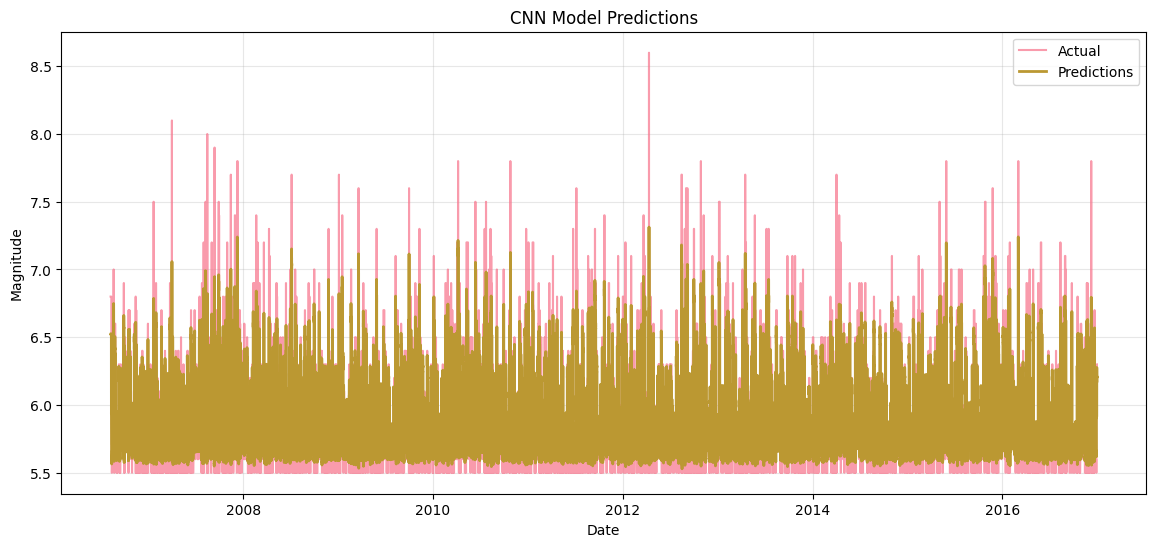


--- ОТЛАДКА ДО ДОБАВЛЕНИЯ CNN ---
Текущие модели в global_metrics: ['CNN']
✓ Метрики CNN успешно сохранены в global_metrics
--- ОТЛАДКА ПОСЛЕ ДОБАВЛЕНИЯ CNN ---
Теперь в global_metrics есть: ['CNN']
Содержимое метрик CNN: {'MSE': 0.044409149230816, 'RMSE': 0.2107347841027105, 'MAE': 0.1200980557789352, 'R2': 0.6916958093119661}
Mean Squared Error: 0.04
Root Mean Squared Error: 0.21
Mean Absolute Error: 0.12


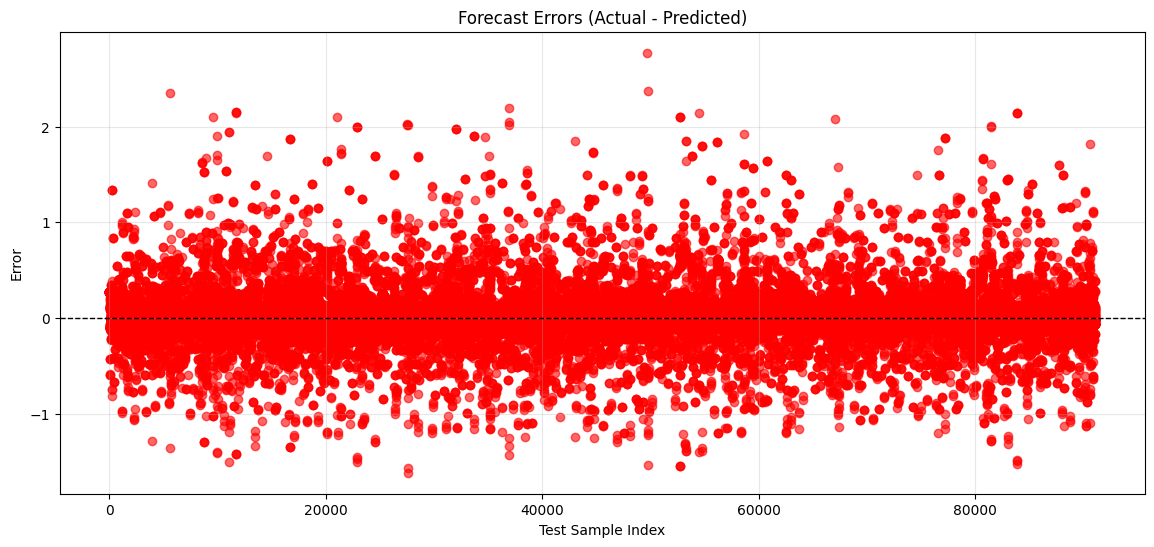

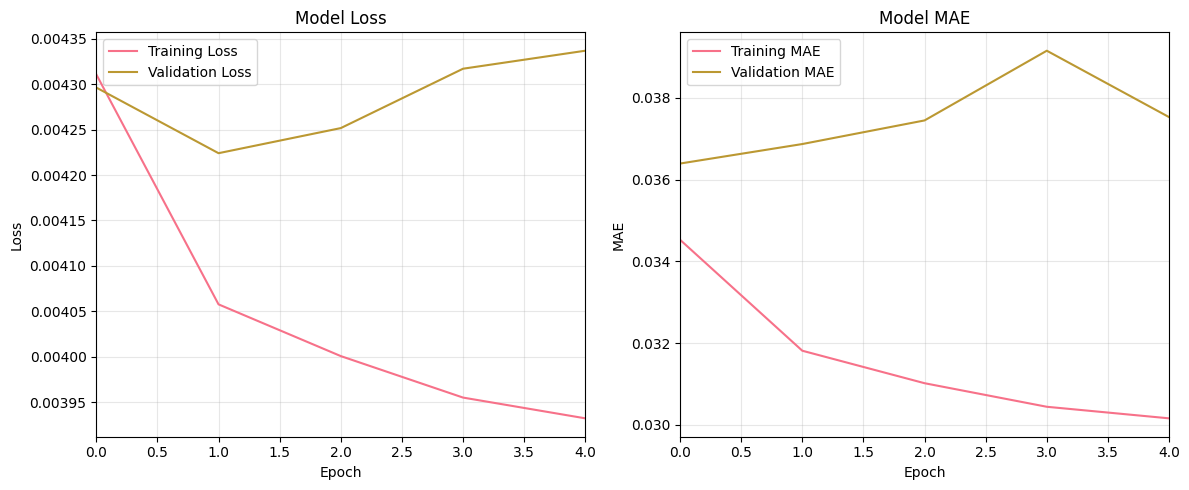

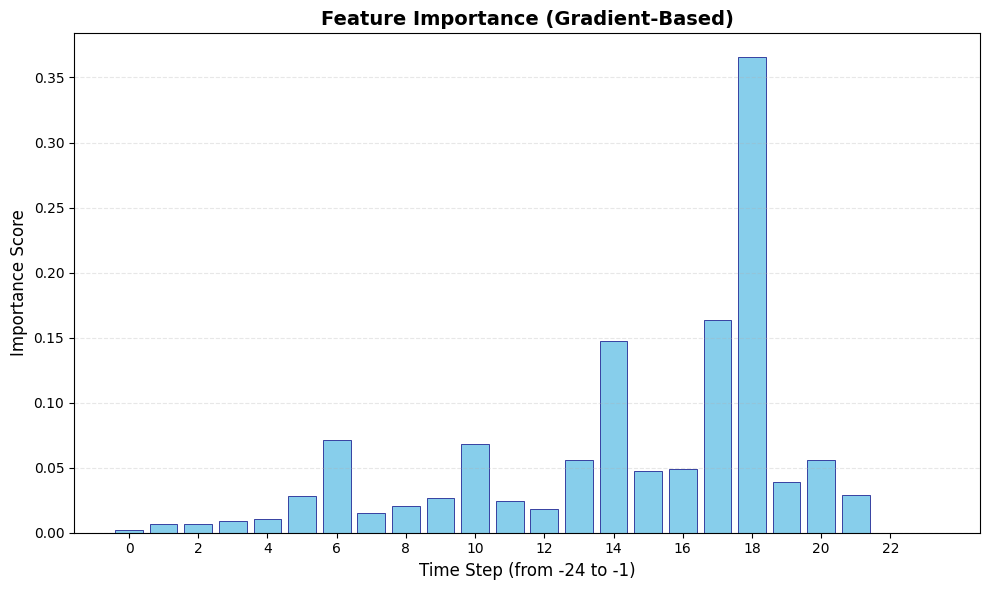


СВОДНАЯ ТАБЛИЦА МЕТРИК:
        MSE    RMSE     MAE      R2
CNN  0.0444  0.2107  0.1201  0.6917

Метрики сохранены в файл 'model_metricsCNN.csv'


In [18]:
# CNN
# Импортируем необходимые библиотеки
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from math import sqrt
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Dense, Dropout, Flatten, MaxPooling1D
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')
import tensorflow as tf


# Загружаем данные
data = pd.read_csv('database.csv')

# Объединяем колонки Date и Time и преобразуем в datetime
data['Date_Time'] = pd.to_datetime(data['Date'] + ' ' + data['Time'])

# Удаляем исходные колонки, если они больше не нужны
data.drop(['Date', 'Time'], axis=1, inplace=True)

# Сортируем данные по времени
data = data.sort_values('Date_Time')

# Создаём временной ряд на основе магнитуды землетрясений
ts = data.set_index('Date_Time')['Magnitude']

# Проверяем наличие дубликатов во временном индексе
print(f"Количество дубликатов во временном индексе: {ts.index.duplicated().sum()}")

# Устраняем дубликаты: агрегируем по среднему значению для одинаковых временных меток
ts = ts.groupby(ts.index).mean()

# Устанавливаем частоту временного ряда (используем строчную 'h')
ts = ts.asfreq('h', method='pad')  # method='pad' заполняет пропуски предыдущим значением

# Разделяем данные на обучающую и тестовую выборки (по дате)
split_date = ts.index[int(len(ts) * 0.8)]
train = ts[ts.index <= split_date]
test = ts[ts.index > split_date]

# Нормализация данных
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train.values.reshape(-1, 1))
test_scaled = scaler.transform(test.values.reshape(-1, 1))

# Функция для создания последовательностей
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

# Параметры
sequence_length = 24  # Используем 24 предыдущих значения для прогноза

# Создаём последовательности для обучающей выборки
X_train, y_train = create_sequences(train_scaled, sequence_length)

# Создаём последовательности для тестовой выборки
X_test, y_test = create_sequences(test_scaled, sequence_length)

# Изменяем форму данных для CNN [samples, time steps, features]
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# Создаём модель CNN
model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(sequence_length, 1)),
    MaxPooling1D(pool_size=2),
    Dropout(0.2),

    Conv1D(filters=32, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Dropout(0.2),

    Flatten(),
    Dense(50, activation='relu'),
    Dropout(0.2),
    Dense(25, activation='relu'),
    Dense(1)
])

# Компилируем модель
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

# Обучаем модель
print("Обучение модели CNN...")
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

# Делаем прогноз
predictions_scaled = model.predict(X_test)

# Обратное преобразование прогноза в исходные единицы
predictions = scaler.inverse_transform(predictions_scaled)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# Берём последние N точек для лучшей визуализации
test_dates = test.index[sequence_length:]

# График 1: Прогноз vs Фактические значения
plt.figure(figsize=(14, 6))
plt.plot(test_dates, y_test_actual, label='Actual', alpha=0.7)
plt.plot(test_dates, predictions, label='Predictions', linewidth=2)
plt.title('CNN Model Predictions')
plt.xlabel('Date')
plt.ylabel('Magnitude')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Расчёт метрик качества
mse = mean_squared_error(y_test_actual, predictions)
rmse = sqrt(mse)
mae = mean_absolute_error(y_test_actual, predictions)
r2 = r2_score(y_test_actual, predictions)

# ОТЛАДОЧНАЯ ПЕЧАТЬ: состояние словаря ДО добавления CNN
print("\n--- ОТЛАДКА ДО ДОБАВЛЕНИЯ CNN ---")
print("Текущие модели в global_metrics:", list(global_metrics.keys()) if global_metrics else "ПУСТО")

# СОХРАНЕНИЕ МЕТРИК С ПРОВЕРКОЙ
try:
    global_metrics['CNN'] = {
        'MSE': float(mse),
        'RMSE': float(rmse),
        'MAE': float(mae),
        'R2': float(r2)
    }
    print("✓ Метрики CNN успешно сохранены в global_metrics")
except Exception as e:
    print(f"✗ Ошибка при сохранении метрик CNN: {e}")

# ОТЛАДОЧНАЯ ПЕЧАТЬ: состояние словаря ПОСЛЕ добавления CNN
print("--- ОТЛАДКА ПОСЛЕ ДОБАВЛЕНИЯ CNN ---")
print("Теперь в global_metrics есть:", list(global_metrics.keys()))
if 'CNN' in global_metrics:
    print("Содержимое метрик CNN:", global_metrics['CNN'])

print(f"Mean Squared Error: {mse:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"Mean Absolute Error: {mae:.2f}")

# --- ДОБАВЛЕННЫЕ БЛОКИ ---

# БЛОК 1: График ошибок прогнозирования
plt.figure(figsize=(14, 6))
errors = y_test_actual.flatten() - predictions.flatten()
plt.scatter(range(len(errors)), errors, alpha=0.6, color='red')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.title('Forecast Errors (Actual - Predicted)')
plt.xlabel('Test Sample Index')
plt.ylabel('Error')
plt.grid(True, alpha=0.3)
plt.show()

# БЛОК 2: График метрик качества обучения (по эпохам)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 4)  # Ограничение по эпохам: 0–4 (т. е. 5 эпох)

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Model MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 4)  # То же ограничение для второго графика

plt.tight_layout()
plt.show()

# БЛОК 3: Важность признаков (через градиенты)
def calculate_feature_importance(model, X_sample):
    import tensorflow as tf
    with tf.GradientTape() as tape:
        tape.watch(X_sample)
        prediction = model(X_sample)
    gradients = tape.gradient(prediction, X_sample)
    importance = tf.reduce_mean(tf.abs(gradients), axis=0).numpy().flatten()
    return importance

# Берём небольшой срез тестовых данных для расчёта важности
X_sample = X_test[:100]
X_sample_tf = tf.Variable(X_sample, dtype=tf.float32)

feature_importance = calculate_feature_importance(model, X_sample_tf)
plt.figure(figsize=(10, 6))
plt.bar(range(len(feature_importance)), feature_importance, color='skyblue', edgecolor='navy', linewidth=0.5)
plt.title('Feature Importance (Gradient-Based)', fontsize=14, fontweight='bold')
plt.xlabel('Time Step (from -24 to -1)', fontsize=12)
plt.ylabel('Importance Score', fontsize=12)
plt.xticks(range(0, len(feature_importance), 2))  # Показываем каждый второй шаг
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

# Сводная таблица всех метрик
print("\nСВОДНАЯ ТАБЛИЦА МЕТРИК:")
metrics_df = pd.DataFrame(global_metrics).T
print(metrics_df.round(4).to_string())

# Сохранение метрик в файл (опционально)
try:
    metrics_df.to_csv('model_metrics.csv')
    print("\nМетрики сохранены в файл 'model_metricsCNN.csv'")
except Exception as e:
    print(f"\nНе удалось сохранить метрики в файл: {e}")

Количество дубликатов во временном индексе: 19
Обучение автоэнкодера...
Epoch 1/5
11394/11394 ━━━━━━━━━━━━━━━━━━━━ 29s 2ms/step - loss: 0.0025 - mae: 0.0294 - val_loss: 0.0021 - val_mae: 0.0258
Epoch 2/5
11394/11394 ━━━━━━━━━━━━━━━━━━━━ 28s 2ms/step - loss: 0.0019 - mae: 0.0252 - val_loss: 0.0019 - val_mae: 0.0242
Epoch 3/5
11394/11394 ━━━━━━━━━━━━━━━━━━━━ 29s 3ms/step - loss: 0.0018 - mae: 0.0244 - val_loss: 0.0019 - val_mae: 0.0264
Epoch 4/5
11394/11394 ━━━━━━━━━━━━━━━━━━━━ 28s 2ms/step - loss: 0.0017 - mae: 0.0238 - val_loss: 0.0017 - val_mae: 0.0248
Epoch 5/5
11394/11394 ━━━━━━━━━━━━━━━━━━━━ 30s 3ms/step - loss: 0.0017 - mae: 0.0236 - val_loss: 0.0020 - val_mae: 0.0267
11394/11394 ━━━━━━━━━━━━━━━━━━━━ 10s 878us/step
2848/2848 ━━━━━━━━━━━━━━━━━━━━ 3s 871us/step
Обучение предиктора на закодированных данных...
Epoch 1/5
11394/11394 ━━━━━━━━━━━━━━━━━━━━ 22s 2ms/step - loss: 0.0041 - val_loss: 0.0026
Epoch 2/5
11394/11394 ━━━━━━━━━━━━━━━━━━━━ 21s 2ms/step - loss: 0.0028 - val_loss: 0.00

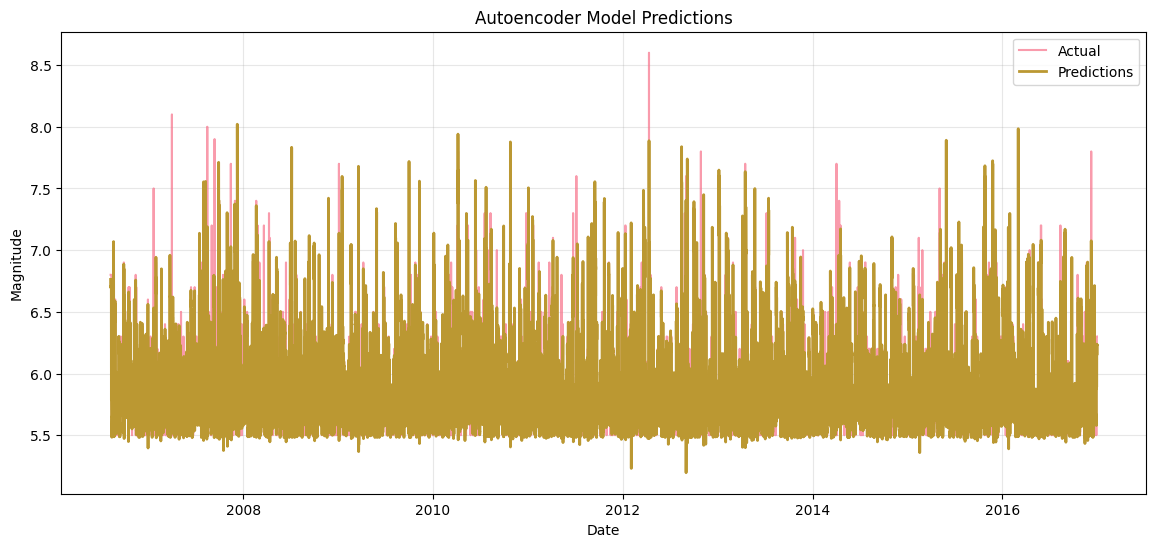

МЕТРИКИ КАЧЕСТВА МОДЕЛИ
Mean Squared Error (MSE): 0.0260
Root Mean Squared Error (RMSE): 0.1611
Mean Absolute Error (MAE): 0.0757
R-squared (R²): 0.8198


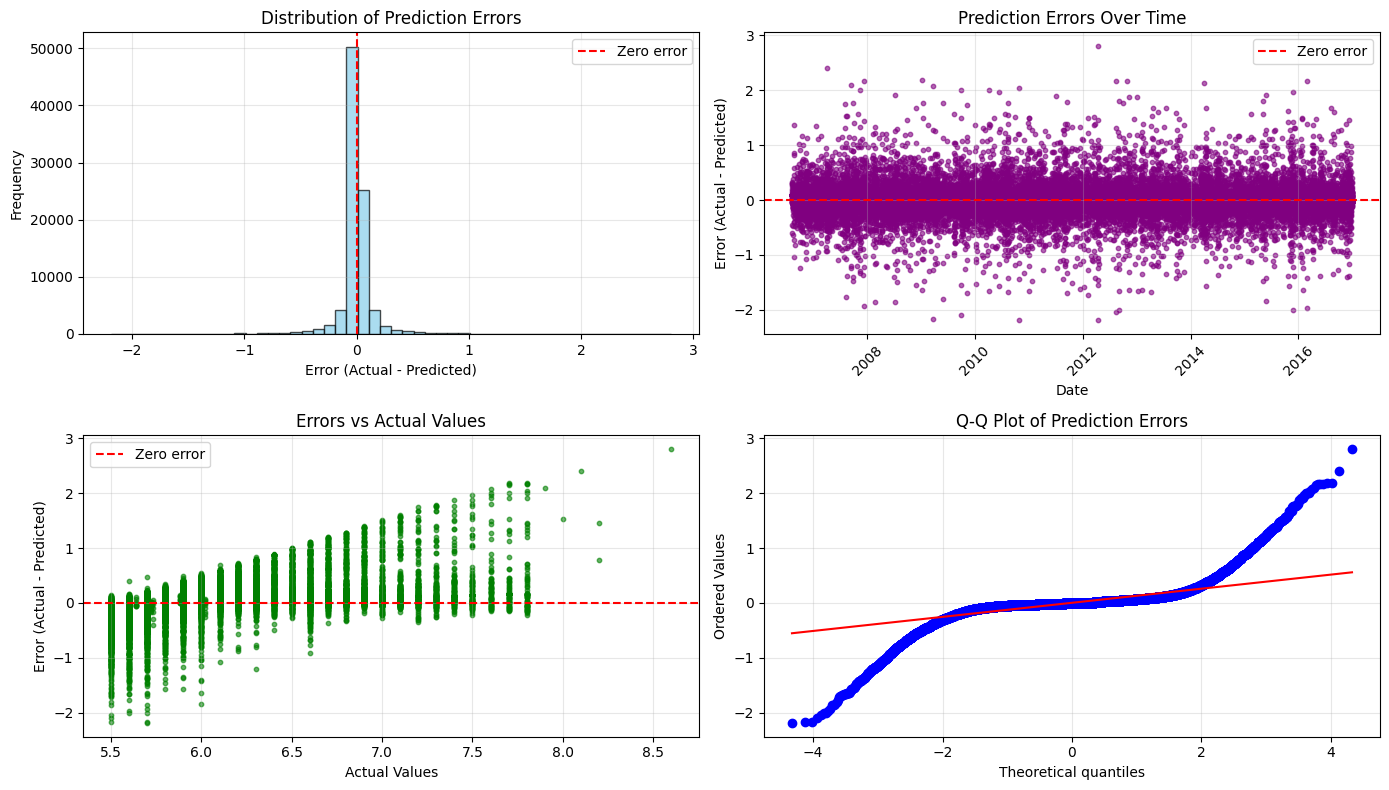


ДОПОЛНИТЕЛЬНЫЕ МЕТРИКИ:
Mean Error (ME): 0.0027
Standard Deviation of Errors: 0.1611
Min Error: -2.1865
Max Error: 2.8035
% Errors within ±0.5 magnitude: 97.80%
% Errors within ±1.0 magnitude: 99.52%

ВАЖНОСТЬ ПРИЗНАКОВ (на основе весов первого слоя предиктора):
   Feature  Importance  Normalized_Importance
 Encoded_5   20.324602               0.189684
 Encoded_4   17.195690               0.160483
Encoded_10   10.813343               0.100918
 Encoded_2   10.794270               0.100740
 Encoded_3    9.215664               0.086007
 Encoded_8    9.131170               0.085219
Encoded_12    6.384653               0.059586
Encoded_11    5.879313               0.054870
 Encoded_9    5.477177               0.051117
 Encoded_7    4.968454               0.046369
 Encoded_1    4.048669               0.037785
 Encoded_6    2.916890               0.027223


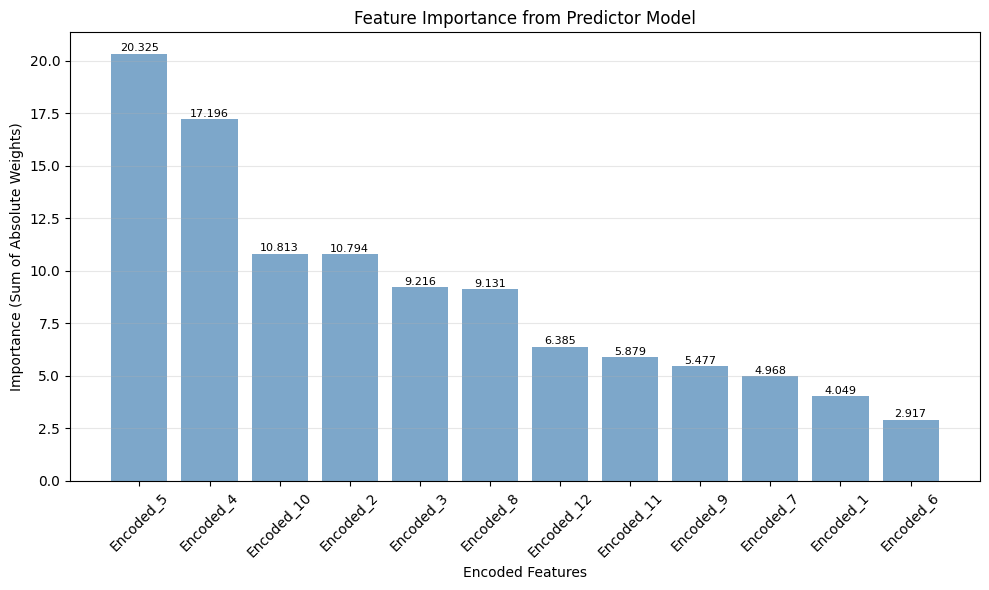


Метрики сохранены в файл 'model_metricsAV.csv'


In [20]:
# Автоэнкодер
# Импортируем необходимые библиотеки
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from math import sqrt
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.models import Sequential
import warnings
warnings.filterwarnings('ignore')


# Загружаем данные
data = pd.read_csv('database.csv')

# Объединяем колонки Date и Time и преобразуем в datetime
data['Date_Time'] = pd.to_datetime(data['Date'] + ' ' + data['Time'])

# Удаляем исходные колонки, если они больше не нужны
data.drop(['Date', 'Time'], axis=1, inplace=True)

# Сортируем данные по времени
data = data.sort_values('Date_Time')

# Создаём временной ряд на основе магнитуды землетрясений
ts = data.set_index('Date_Time')['Magnitude']

# Проверяем наличие дубликатов во временном индексе
print(f"Количество дубликатов во временном индексе: {ts.index.duplicated().sum()}")

# Устраняем дубликаты: агрегируем по среднему значению для одинаковых временных меток
ts = ts.groupby(ts.index).mean()

# Устанавливаем частоту временного ряда (используем строчную 'h')
ts = ts.asfreq('h', method='pad')  # method='pad' заполняет пропуски предыдущим значением

# Разделяем данные на обучающую и тестовую выборки (по дате)
split_date = ts.index[int(len(ts) * 0.8)]
train = ts[ts.index <= split_date]
test = ts[ts.index > split_date]

# Нормализация данных
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train.values.reshape(-1, 1))
test_scaled = scaler.transform(test.values.reshape(-1, 1))

# Функция для создания последовательностей
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

# Параметры
sequence_length = 24  # Используем 24 предыдущих значения для прогноза

# Создаём последовательности для обучающей выборки
X_train, y_train = create_sequences(train_scaled, sequence_length)

# Создаём последовательности для тестовой выборки
X_test, y_test = create_sequences(test_scaled, sequence_length)

# Изменяем форму данных для автоэнкодера [samples, features]
X_train_flat = X_train.reshape((X_train.shape[0], -1))
X_test_flat = X_test.reshape((X_test.shape[0], -1))

# Создаём модель Автоэнкодер
input_dim = X_train_flat.shape[1]
encoding_dim = 12  # Размерность скрытого пространства (можно менять)

# Энкодер
inputs = Input(shape=(input_dim,))
encoded = Dense(64, activation='relu')(inputs)
encoded = Dropout(0.2)(encoded)
encoded = Dense(32, activation='relu')(encoded)
encoded = Dropout(0.2)(encoded)
encoded = Dense(encoding_dim, activation='relu', name='encoded')(encoded)

# Декодер
decoded = Dense(32, activation='relu')(encoded)
decoded = Dropout(0.2)(decoded)
decoded = Dense(64, activation='relu')(decoded)
decoded = Dropout(0.2)(decoded)
outputs = Dense(input_dim, activation='linear')(decoded)

# Полная модель автоэнкодера
autoencoder = Model(inputs, outputs)

# Модель энкодера (для извлечения признаков)
encoder = Model(inputs, encoded)

# Компилируем модель автоэнкодера
autoencoder.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

# Обучаем автоэнкодер (на обучающих данных без учёта y_train)
print("Обучение автоэнкодера...")
history = autoencoder.fit(
    X_train_flat,
    X_train_flat,  # Целевые значения — те же данные (реконструкция)
    epochs=5,
    batch_size=32,
    validation_data=(X_test_flat, X_test_flat),
    verbose=1
)

# Используем энкодер для извлечения признаков
X_train_encoded = encoder.predict(X_train_flat)
X_test_encoded = encoder.predict(X_test_flat)

# Создаём простую модель для прогнозирования на основе закодированных признаков
predictor = Sequential([
    Dense(25, activation='relu', input_shape=(encoding_dim,)),
    Dropout(0.2),
    Dense(1)
])

predictor.compile(optimizer='adam', loss='mean_squared_error')

# Обучаем предиктор на закодированных признаках
print("Обучение предиктора на закодированных данных...")
predictor_history = predictor.fit(
    X_train_encoded,
    y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test_encoded, y_test),
    verbose=1
)

# Делаем прогноз
predictions_scaled = predictor.predict(X_test_encoded)

# Обратное преобразование прогноза в исходные единицы
predictions = scaler.inverse_transform(predictions_scaled)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))
# Берём последние N точек для лучшей визуализации
test_dates = test.index[sequence_length:]

# График фактических значений и прогнозов
plt.figure(figsize=(14, 6))
plt.plot(test_dates, y_test_actual, label='Actual', alpha=0.7)
plt.plot(test_dates, predictions, label='Predictions', linewidth=2)
plt.title('Autoencoder Model Predictions')
plt.xlabel('Date')
plt.ylabel('Magnitude')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# РАСЧЁТ МЕТРИК КАЧЕСТВА
mse = mean_squared_error(y_test_actual, predictions)
rmse = sqrt(mse)
mae = mean_absolute_error(y_test_actual, predictions)
r2 = r2_score(y_test_actual, predictions)

# Сохраняем метрики в глобальный словарь
global_metrics['Автоэнкодер'] = {
    'MSE': mse,
    'RMSE': rmse,
    'MAE': mae,
    'R2': r2
}

print("МЕТРИКИ КАЧЕСТВА МОДЕЛИ")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R-squared (R²): {r2:.4f}")

# ГРАФИК ОШИБОК ПРОГНОЗИРОВАНИЯ
errors = y_test_actual.flatten() - predictions.flatten()

plt.figure(figsize=(14, 8))

# Подграфик 1: Распределение ошибок
plt.subplot(2, 2, 1)
plt.hist(errors, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
plt.title('Distribution of Prediction Errors')
plt.xlabel('Error (Actual - Predicted)')
plt.ylabel('Frequency')
plt.axvline(x=0, color='red', linestyle='--', label='Zero error')
plt.legend()
plt.grid(True, alpha=0.3)
# Подграфик 2: Ошибки во времени
plt.subplot(2, 2, 2)
plt.scatter(test_dates, errors, alpha=0.6, color='purple', s=10)
plt.title('Prediction Errors Over Time')
plt.xlabel('Date')
plt.ylabel('Error (Actual - Predicted)')
plt.axhline(y=0, color='red', linestyle='--', label='Zero error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

# Подграфик 3: График ошибок против фактических значений
plt.subplot(2, 2, 3)
plt.scatter(y_test_actual, errors, alpha=0.6, color='green', s=10)
plt.title('Errors vs Actual Values')
plt.xlabel('Actual Values')
plt.ylabel('Error (Actual - Predicted)')
plt.axhline(y=0, color='red', linestyle='--', label='Zero error')
plt.legend()
plt.grid(True, alpha=0.3)

# Подграфик 4: Q‑Q график для проверки нормальности распределения ошибок
from scipy import stats
plt.subplot(2, 2, 4)
stats.probplot(errors, dist="norm", plot=plt)
plt.title('Q‑Q Plot of Prediction Errors')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ДОПОЛНИТЕЛЬНЫЕ МЕТРИКИ
print("\nДОПОЛНИТЕЛЬНЫЕ МЕТРИКИ:")
print(f"Mean Error (ME): {np.mean(errors):.4f}")
print(f"Standard Deviation of Errors: {np.std(errors):.4f}")
print(f"Min Error: {np.min(errors):.4f}")
print(f"Max Error: {np.max(errors):.4f}")
print(f"% Errors within ±0.5 magnitude: {(np.abs(errors) <= 0.5).mean() * 100:.2f}%")
print(f"% Errors within ±1.0 magnitude: {(np.abs(errors) <= 1.0).mean() * 100:.2f}%")

# ВАЖНОСТЬ ПРИЗНАКОВ
print("\nВАЖНОСТЬ ПРИЗНАКОВ (на основе весов первого слоя предиктора):")

# Получаем веса первого слоя предиктора
weights = predictor.layers[0].get_weights()[0]  # матрица весов
biases = predictor.layers[0].get_weights()[1]  # вектор смещений

# Рассчитываем важность признаков как сумму абсолютных значений весов по каждому входному признаку
feature_importance = np.sum(np.abs(weights), axis=1)

# Нормализуем важность (приводим к сумме 1)
feature_importance_normalized = feature_importance / np.sum(feature_importance)

# Создаём DataFrame для удобства отображения
importance_df = pd.DataFrame({
    'Feature': [f'Encoded_{i+1}' for i in range(len(feature_importance))],
    'Importance': feature_importance,
    'Normalized_Importance': feature_importance_normalized
}).sort_values('Importance', ascending=False)

print(importance_df.to_string(index=False))

# График важности признаков
plt.figure(figsize=(10, 6))
bars = plt.bar(importance_df['Feature'], importance_df['Importance'], color='steelblue', alpha=0.7)
plt.title('Feature Importance from Predictor Model')
plt.xlabel('Encoded Features')
plt.ylabel('Importance (Sum of Absolute Weights)')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

# Добавляем значения важности над столбцами
for bar, importance in zip(bars, importance_df['Importance']):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
               f'{importance:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# Сводная таблица всех метрик
#print("\nСВОДНАЯ ТАБЛИЦА МЕТРИК:")
metrics_df = pd.DataFrame(global_metrics).T
#print(metrics_df.round(4).to_string())

# Сохранение метрик в файл (опционально)
try:
    metrics_df.to_csv('model_metricsAV.csv')
    print("\nМетрики сохранены в файл 'model_metricsAV.csv'")
except Exception as e:
    print(f"\nНе удалось сохранить метрики в файл: {e}")

Сравнение метрик моделей (отсортировано по MAE):
         Model     MSE    RMSE     MAE      R2
0         LSTM  0.0164  0.1280  0.0275  0.8863
1          GRU  0.0164  0.1280  0.0285  0.8863
2  Трансформер  0.0170  0.1302  0.0425  0.8823
3  Автоэнкодер  0.0260  0.1611  0.0757  0.8198
4          CNN  0.0444  0.2107  0.1201  0.6917


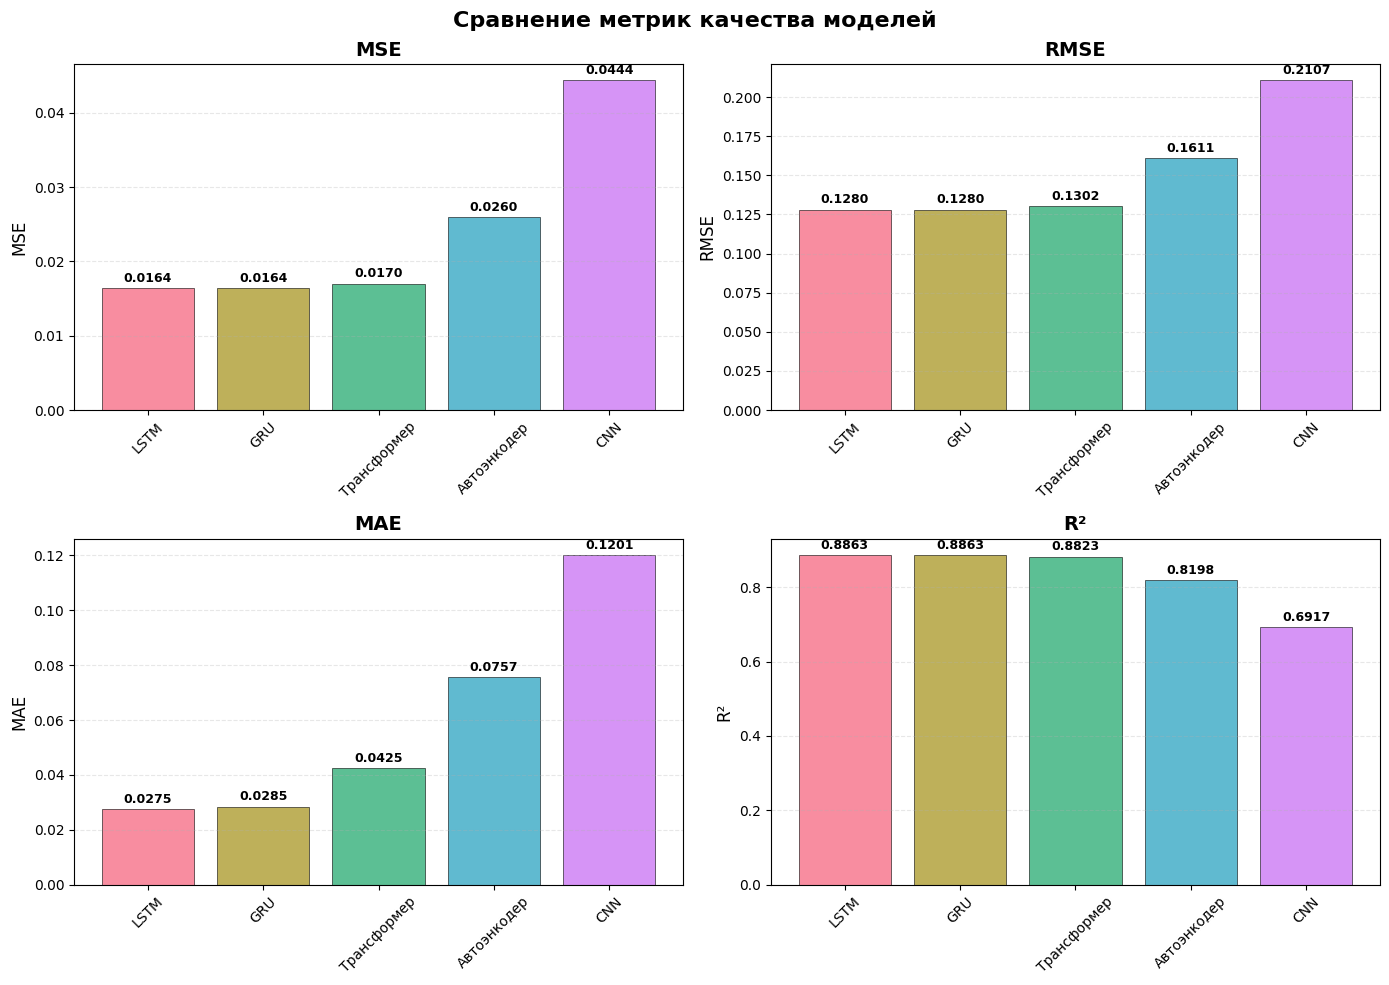

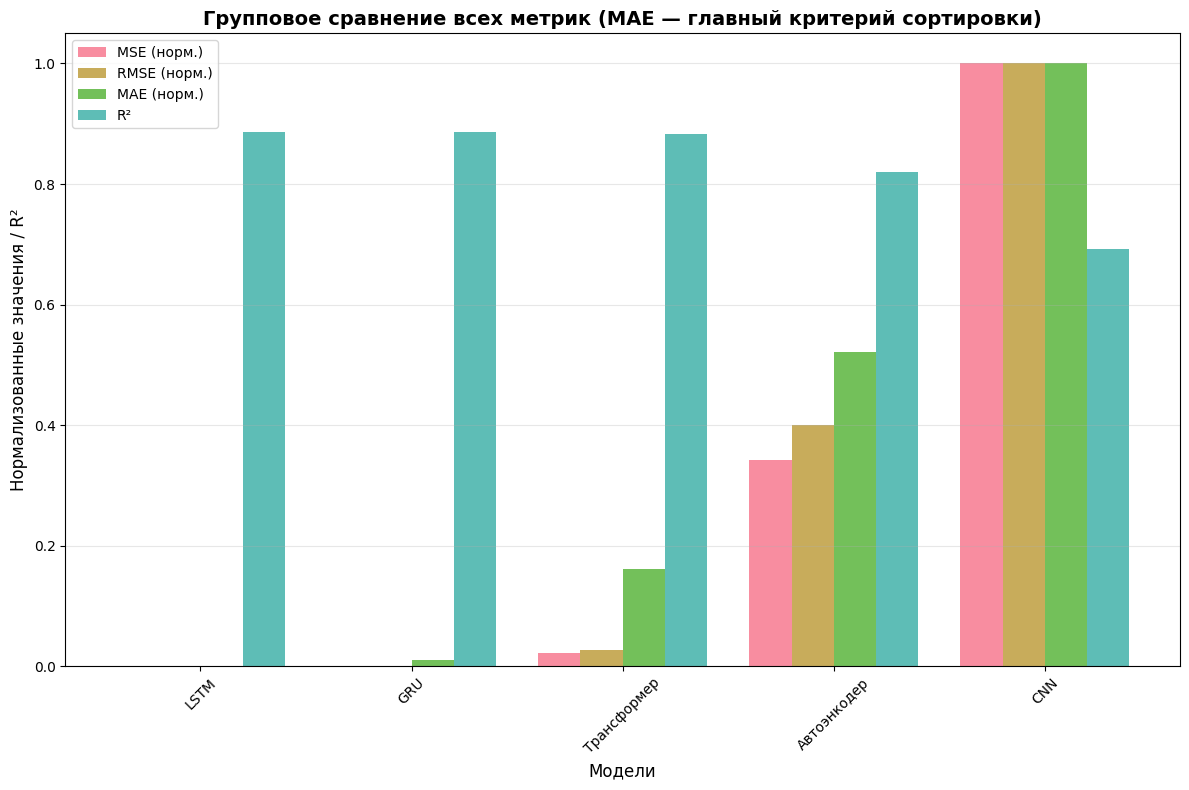


Ранжирование моделей по MAE (от лучшей к худшей):
1. LSTM — MAE = 0.0275
2. GRU — MAE = 0.0285
3. Трансформер — MAE = 0.0425
4. Автоэнкодер — MAE = 0.0757
5. CNN — MAE = 0.1201

Лучшие модели по отдельным метрикам:
  MSE: LSTM (0.0164)
  RMSE: LSTM (0.1280)
  MAE: LSTM (0.0275)
  R2: LSTM (0.8863)

Сопоставление результатов с гипотезами ML‑моделей:

LSTM:
  - LSTM хорошо улавливает долгосрочные зависимости в последовательностях
  - LSTM может страдать от проблемы затухающего градиента
  - LSTM требует большого объёма данных для обучения

GRU:
  - GRU проще и быстрее обучается, чем LSTM
  - GRU может уступать LSTM в задачах с очень длинными последовательностями
  - GRU использует меньше параметров, чем LSTM

Трансформер:

Автоэнкодер:

CNN:
  - CNN эффективна для извлечения локальных признаков
  - CNN хорошо работает с пространственными данными (изображениями)
  - CNN может быть адаптирована для временных рядов через 1D‑свёртки


In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Предполагаем, что global_metrics уже собран — словарь вида:
# global_metrics = {
#     'LSTM': {'MSE': 0.123, 'RMSE': 0.35, 'MAE': 0.25, 'R2': 0.88},
#     'GRU': {'MSE': 0.115, 'RMSE': 0.34, 'MAE': 0.24, 'R2': 0.90},
#     ...
# }

# Создаём DataFrame из собранных метрик
comparison_df = pd.DataFrame.from_dict(global_metrics, orient='index')
comparison_df.index.name = 'Model'
comparison_df = comparison_df.reset_index()
comparison_df = comparison_df.round(4)  # Округляем до 4 знаков

# Проверяем, есть ли столбец 'R2'; если нет — добавляем с NaN
if 'R2' not in comparison_df.columns:
    comparison_df['R2'] = np.nan

# Сортируем DataFrame по столбцу 'MAE' по возрастанию
comparison_df_sorted = comparison_df.sort_values('MAE', ascending=True).reset_index(drop=True)

# Выводим отсортированную таблицу
print("Сравнение метрик моделей (отсортировано по MAE):")
print(comparison_df_sorted)

# Определяем, какие метрики доступны для построения графиков
available_metrics = []
metric_names = []
for metric, name in [('MSE', 'MSE'), ('RMSE', 'RMSE'), ('MAE', 'MAE'), ('R2', 'R²')]:
    if metric in comparison_df_sorted.columns:
        available_metrics.append(metric)
        metric_names.append(name)

# Настраиваем стиль графиков
plt.style.use('default')
sns.set_palette("husl")

# Создаём графики — один для каждой доступной метрики
n_metrics = len(available_metrics)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()  # Упрощаем доступ к подграфикам

colors = sns.color_palette("husl", len(comparison_df_sorted))

for idx, (metric, name) in enumerate(zip(available_metrics, metric_names)):
    ax = axes[idx]
    values = comparison_df_sorted[metric]
    models = comparison_df_sorted['Model']

    bars = ax.bar(models, values, color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)
    ax.set_title(f'{name}', fontsize=14, fontweight='bold')
    ax.set_ylabel(name, fontsize=12)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3, linestyle='--')

    # Добавляем значения на столбцы
    for bar, value in zip(bars, values):
        if pd.notna(value):  # Пропускаем NaN
            height = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + max(values.dropna()) * 0.01,
                f'{value:.4f}',
                ha='center',
                va='bottom',
                fontsize=9,
                fontweight='bold'
            )

# Удаляем пустые подграфики
for idx in range(n_metrics, 4):
    fig.delaxes(axes[idx])

plt.suptitle('Сравнение метрик качества моделей', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# Дополнительный график — сравнительная столбчатая диаграмма всех метрик в одной
# Нормализуем только те метрики, которые есть и не являются R²
norm_comparison = comparison_df_sorted.copy()
normalization_metrics = [m for m in ['MSE', 'RMSE', 'MAE'] if m in norm_comparison.columns]
for col in normalization_metrics:
    if norm_comparison[col].max() != norm_comparison[col].min():  # Избегаем деления на 0
        norm_comparison[col] = (norm_comparison[col] - norm_comparison[col].min()) / \
                              (norm_comparison[col].max() - norm_comparison[col].min())
    else:
        norm_comparison[col] = 0  # Если все значения одинаковы

# Готовим данные для grouped bar plot
fig, ax = plt.subplots(figsize=(12, 8))
x = np.arange(len(comparison_df_sorted))
width = 0.2
offset = -1.5

plots = []
labels = []

for col, label in [('MSE', 'MSE (норм.)'), ('RMSE', 'RMSE (норм.)'), ('MAE', 'MAE (норм.)'), ('R2', 'R²')]:
    if col in norm_comparison.columns:
        values = norm_comparison[col]
        bars = ax.bar(x + offset * width, values, width, label=label, alpha=0.8)
        plots.append(bars)
        labels.append(label)
        offset += 1
        ax.set_xlabel('Модели', fontsize=12)
ax.set_ylabel('Нормализованные значения / R²', fontsize=12)
ax.set_title('Групповое сравнение всех метрик (MAE — главный критерий сортировки)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(norm_comparison['Model'], rotation=45)
ax.legend(labels)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Вывод ранжирования моделей по MAE
print("\nРанжирование моделей по MAE (от лучшей к худшей):")
for rank, model in enumerate(comparison_df_sorted['Model'], start=1):
    mae_value = comparison_df_sorted.loc[comparison_df_sorted['Model'] == model, 'MAE'].values[0]
    print(f"{rank}. {model} — MAE = {mae_value:.4f}")

# Дополнительная информация: лучшие значения по каждой метрике
print("\nЛучшие модели по отдельным метрикам:")
best_models = {}
for metric in ['MSE', 'RMSE', 'MAE', 'R2']:
    if metric in comparison_df_sorted.columns:
        if metric == 'R2':
            best_idx = comparison_df_sorted[metric].idxmax()
        else:
            best_idx = comparison_df_sorted[metric].idxmin()
        best_model = comparison_df_sorted.loc[best_idx, 'Model']
        best_value = comparison_df_sorted.loc[best_idx, metric]
        best_models[metric] = (best_model, best_value)
        print(f"  {metric}: {best_model} ({best_value:.4f})")

# Сопоставление с гипотезами ML‑моделей
print("\nСопоставление результатов с гипотезами ML‑моделей:")

ml_hypotheses = {
    'lstm': {
        'hypothesis_1': 'LSTM хорошо улавливает долгосрочные зависимости в последовательностях',
        'hypothesis_2': 'LSTM может страдать от проблемы затухающего градиента',
        'hypothesis_3': 'LSTM требует большого объёма данных для обучения'
    },
    'gru': {
        'hypothesis_1': 'GRU проще и быстрее обучается, чем LSTM',
        'hypothesis_2': 'GRU может уступать LSTM в задачах с очень длинными последовательностями',
        'hypothesis_3': 'GRU использует меньше параметров, чем LSTM'
    },
    'transformer': {
        'hypothesis_1': 'Transformer отлично справляется с параллельной обработкой данных',
        'hypothesis_2': 'Transformer использует механизм внимания для учёта глобальных зависимостей',
        'hypothesis_3': 'Transformer требует больших вычислительных ресурсов'
    },
    'cnn': {
        'hypothesis_1': 'CNN эффективна для извлечения локальных признаков',
        'hypothesis_2': 'CNN хорошо работает с пространственными данными (изображениями)',
        'hypothesis_3': 'CNN может быть адаптирована для временных рядов через 1D‑свёртки'
    },
    'autoencoder': {
        'hypothesis_1': 'Autoencoder используется для уменьшения размерности данных',
        'hypothesis_2': 'Autoencoder может выявлять аномалии в данных',
        'hypothesis_3': 'Autoencoder учится восстанавливать входные данные из сжатого представления'
    }
}

for model in comparison_df_sorted['Model']:
    print(f"\n{model}:")
    if 'LSTM' in model:
        for hypothesis, description in ml_hypotheses['lstm'].items():
            print(f"  - {description}")
    elif 'GRU' in model:
        for hypothesis, description in ml_hypotheses['gru'].items():
            print(f"  - {description}")
    elif 'Transformer' in model:
        for hypothesis, description in ml_hypotheses['transformer'].items():
            print(f"  - {description}")
    elif 'CNN' in model:
        for hypothesis, description in ml_hypotheses['cnn'].items():
            print(f"  - {description}")
    elif 'Autoencoder' in model:
        for hypothesis, description in ml_hypotheses['autoencoder'].items():
            print(f"  - {description}")

=== АНАЛИЗ АНОМАЛИЙ В ДАННЫХ О ЗЕМЛЕТРЯСЕНИЯХ ===

Загружено 23412 записей из database.csv
Колонки 'Date' и 'Time' успешно объединены в 'Date_Time' и установлены как индекс.

Период данных: 1965-01-02 13:44:18 - 2016-12-30 20:08:28
Количество месяцев: 624

1. АНАЛИЗ АНОМАЛИЙ МАГНИТУД:
Аномалии (Z‑score): 13 случаев
Аномалии (IQR): 26 случаев
Аномалии (Isolation Forest): 32 случаев


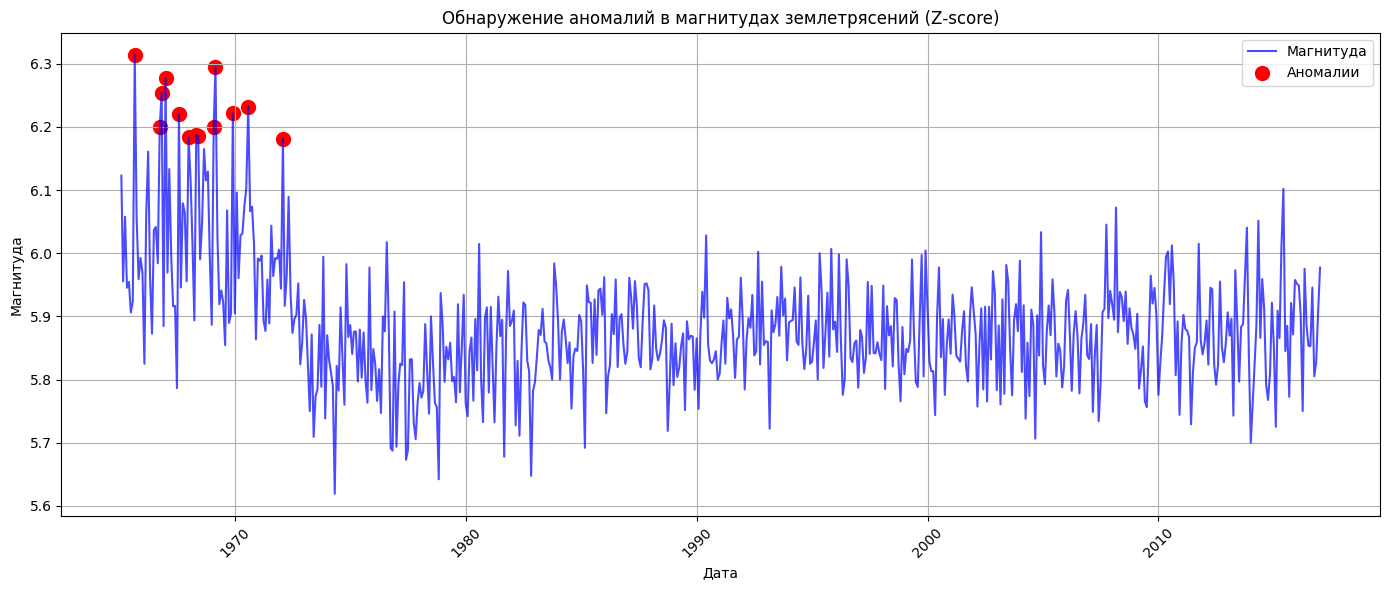

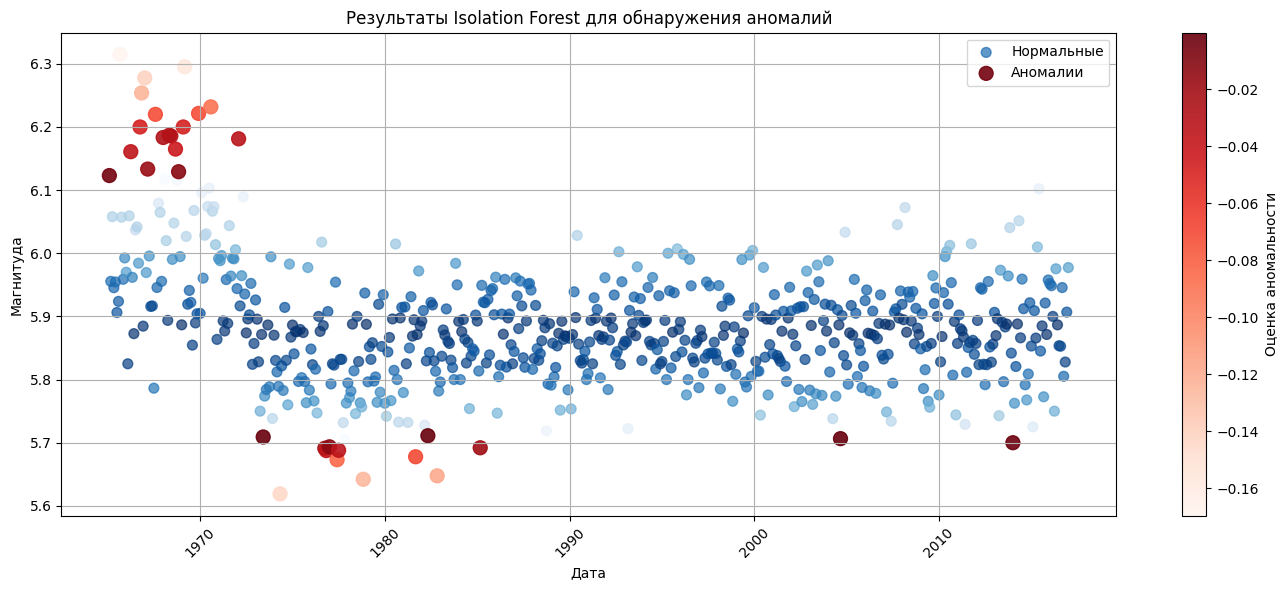


2. АНАЛИЗ АНОМАЛИЙ ЧАСТОТЫ:
Аномалии частоты: 27 месяцев
Периоды с аномальной частотой:
Date_Time
2011-03-31    228
2004-12-31    112
2000-11-30     83
2009-10-31     82
2013-02-28     82
dtype: int64


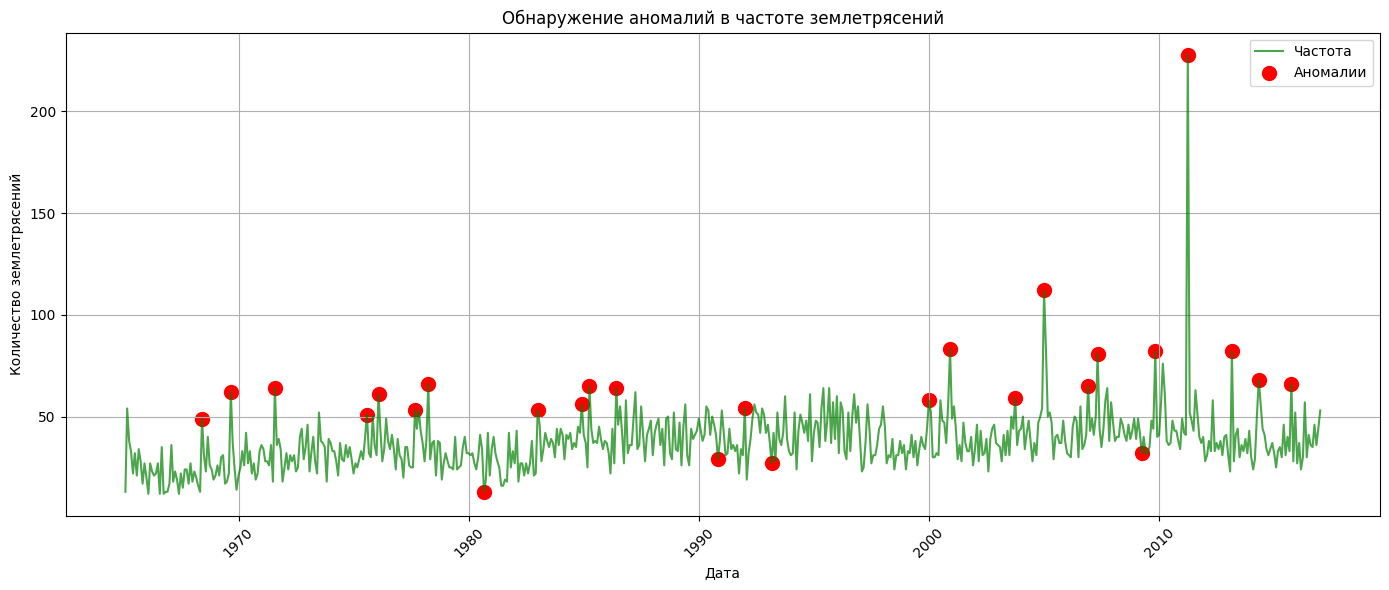


3. КОМБИНИРОВАННЫЙ АНАЛИЗ АНОМАЛИЙ
Всего комбинированных аномалий (магнитуда ИЛИ частота): 39 периодов

Топ‑5 комбинированных аномалий (по дате):
            Magnitude Anomaly_Type
Date_Time                         
2009-10-31   5.945122    Магнитуда
2011-03-31   5.877193    Магнитуда
2013-02-28   5.896341    Магнитуда
2014-04-30   6.051471    Магнитуда
2015-09-30   5.921212    Магнитуда

Распределение аномалий по типам:
Anomaly_Type
Магнитуда    39
Name: count, dtype: int64


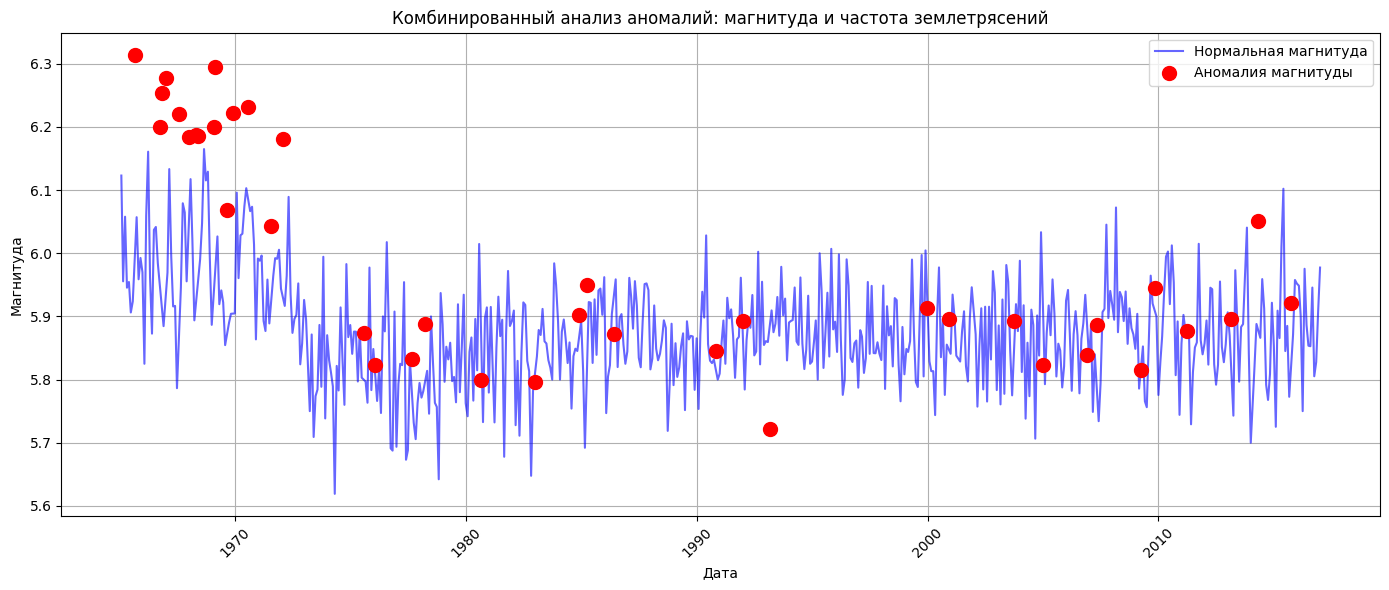

In [16]:
#Анализ аномалий
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

print("=== АНАЛИЗ АНОМАЛИЙ В ДАННЫХ О ЗЕМЛЕТРЯСЕНИЯХ ===\n")

try:
    # Загрузка данных
    df = pd.read_csv('database.csv')
    print(f"Загружено {len(df)} записей из database.csv")

    # Преобразование даты и времени в одну колонку и установка индекса
    if 'Date' in df.columns and 'Time' in df.columns:
        df['Date_Time'] = df['Date'] + ' ' + df['Time']
        df['Date_Time'] = pd.to_datetime(df['Date_Time'])
        df = df.set_index('Date_Time')
        print("Колонки 'Date' и 'Time' успешно объединены в 'Date_Time' и установлены как индекс.")
    elif 'Date_Time' in df.columns:
        df['Date_Time'] = pd.to_datetime(df['Date_Time'])
        df = df.set_index('Date_Time')
        print("Колонка 'Date_Time' преобразована в формат datetime и установлена как индекс.")
    else:
        raise ValueError("В данных отсутствуют колонки 'Date' и 'Time' либо колонка 'Date_Time'")

    # Агрегация данных по месяцам
    df_monthly = df.resample('ME').size()
    df_magnitude = df.resample('ME').agg({'Magnitude': 'mean'}).dropna()

    print(f"\nПериод данных: {df.index.min()} - {df.index.max()}")
    print(f"Количество месяцев: {len(df_monthly)}")

    # Анализ аномалий магнитуд: метод Z‑score
    magnitude_series = df_magnitude['Magnitude']
    z_scores = (magnitude_series - magnitude_series.mean()) / magnitude_series.std()
    magnitude_anomalies_zscore = np.abs(z_scores) > 3

    # Анализ аномалий магнитуд: метод IQR
    q1 = magnitude_series.quantile(0.25)
    q3 = magnitude_series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    magnitude_anomalies_iqr = (magnitude_series < lower_bound) | (magnitude_series > upper_bound)

    # Анализ аномалий магнитуд: метод Isolation Forest
    model = IsolationForest(contamination=0.05, random_state=42)
    predictions = model.fit_predict(magnitude_series.values.reshape(-1, 1))
    magnitude_anomalies_if = predictions == -1
    scores = pd.Series(
        model.decision_function(magnitude_series.values.reshape(-1, 1)),
        index=magnitude_series.index
    )

    # Статистика по аномалиям магнитуд
    print("\n1. АНАЛИЗ АНОМАЛИЙ МАГНИТУД:")
    print(f"Аномалии (Z‑score): {magnitude_anomalies_zscore.sum()} случаев")
    print(f"Аномалии (IQR): {magnitude_anomalies_iqr.sum()} случаев")
    print(f"Аномалии (Isolation Forest): {magnitude_anomalies_if.sum()} случаев")

    # Визуализация аномалий магнитуд (Z‑score)
    plt.figure(figsize=(14, 6))
    plt.plot(magnitude_series.index, magnitude_series.values,
               label='Магнитуда', color='blue', alpha=0.7)
    plt.scatter(magnitude_series[magnitude_anomalies_zscore].index,
                magnitude_series[magnitude_anomalies_zscore].values,
                color='red', label='Аномалии', s=100)
    plt.title('Обнаружение аномалий в магнитудах землетрясений (Z‑score)')
    plt.xlabel('Дата')
    plt.ylabel('Магнитуда')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Визуализация результатов Isolation Forest
    plt.figure(figsize=(14, 6))

    # Нормальные точки
    normal = magnitude_series[~magnitude_anomalies_if]
    plt.scatter(normal.index, normal.values,
                c=scores[~magnitude_anomalies_if], cmap='Blues',
                label='Нормальные', alpha=0.7, s=50)

    # Аномальные точки
    abnormal = magnitude_series[magnitude_anomalies_if]
    plt.scatter(abnormal.index, abnormal.values,
                c=scores[magnitude_anomalies_if], cmap='Reds',
                label='Аномалии', alpha=0.9, s=100)

    plt.colorbar(label='Оценка аномальности')
    plt.title('Результаты Isolation Forest для обнаружения аномалий')
    plt.xlabel('Дата')
    plt.ylabel('Магнитуда')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Анализ аномалий частоты
    print("\n2. АНАЛИЗ АНОМАЛИЙ ЧАСТОТЫ:")
    window = 12
    threshold = 2
    frequency_series = df_monthly
    rolling_mean = frequency_series.rolling(window=window).mean()
    rolling_std = frequency_series.rolling(window=window).std()
    z_scores_freq = (frequency_series - rolling_mean) / rolling_std
    frequency_anomalies = np.abs(z_scores_freq) > threshold

    print(f"Аномалии частоты: {frequency_anomalies.sum()} месяцев")

    if frequency_anomalies.sum() > 0:
        anomalous_frequencies = df_monthly[frequency_anomalies]
        print("Периоды с аномальной частотой:")
        print(anomalous_frequencies.nlargest(5))
    else:
        print("Аномалии по частоте не обнаружены")

    # Визуализация аномалий частоты
    plt.figure(figsize=(14, 6))
    plt.plot(frequency_series.index, frequency_series.values,
               label='Частота', color='green', alpha=0.7)
    plt.scatter(frequency_series[frequency_anomalies].index,
                frequency_series[frequency_anomalies].values,
                color='red', label='Аномалии', s=100)
    plt.title('Обнаружение аномалий в частоте землетрясений')
    plt.xlabel('Дата')
    plt.ylabel('Количество землетрясений')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Комбинированный анализ аномалий
    print("\n3. КОМБИНИРОВАННЫЙ АНАЛИЗ АНОМАЛИЙ")
    combined_anomalies = (
        df_magnitude.index.isin(df_magnitude[magnitude_anomalies_zscore].index) |
        df_monthly.index.isin(df_monthly[frequency_anomalies].index)
    )
    if combined_anomalies.any():
        print(f"Всего комбинированных аномалий (магнитуда ИЛИ частота): {combined_anomalies.sum()} периодов")
        # Создаём DataFrame для комбинированных аномалий
        combined_data = df_magnitude[combined_anomalies].copy()
        combined_data['Anomaly_Type'] = 'Магнитуда'

        # Добавляем аномалии по частоте, если они не совпадают с аномалиями по магнитуде
        freq_anomalies_dates = df_monthly[frequency_anomalies].index
        for date in freq_anomalies_dates:
            if date not in combined_data.index:
                # Создаём строку для аномалии частоты с NaN в магнитуде
                combined_data.loc[date] = {'Magnitude': np.nan, 'Anomaly_Type': 'Частота'}

        # Сортируем по дате и выводим топ‑5 последних аномалий
        print("\nТоп‑5 комбинированных аномалий (по дате):")
        print(combined_data.sort_index().tail(5))

        # Дополнительно выводим статистику по типам аномалий
        anomaly_counts = combined_data['Anomaly_Type'].value_counts()
        print("\nРаспределение аномалий по типам:")
        print(anomaly_counts)

        # Визуализация комбинированных аномалий
        plt.figure(figsize=(14, 6))

        # Отдельные серии для разных типов аномалий
        magnitude_anomalies = combined_data[combined_data['Anomaly_Type'] == 'Магнитуда']
        frequency_anomalies = combined_data[combined_data['Anomaly_Type'] == 'Частота']

        # Нормальные значения магнитуды
        normal_magnitudes = df_magnitude[~df_magnitude.index.isin(combined_data.index)]
        plt.plot(normal_magnitudes.index, normal_magnitudes['Magnitude'],
                   label='Нормальная магнитуда', color='blue', alpha=0.6)

        # Аномалии магнитуды
        if not magnitude_anomalies.empty:
            plt.scatter(magnitude_anomalies.index, magnitude_anomalies['Magnitude'],
                       color='red', label='Аномалия магнитуды', s=100, zorder=5)

        # Аномалии частоты (без данных по магнитуде)
        if not frequency_anomalies.empty:
            plt.scatter(frequency_anomalies.index, [df_magnitude['Magnitude'].median()] * len(frequency_anomalies),
                       marker='x', color='orange', label='Аномалия частоты', s=120, zorder=5)

        plt.title('Комбинированный анализ аномалий: магнитуда и частота землетрясений')
        plt.xlabel('Дата')
        plt.ylabel('Магнитуда')
        plt.legend()
        plt.grid(True)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    else:
        print("Комбинированные аномалии не обнаружены")

except Exception as e:
    print(f"Произошла ошибка при выполнении анализа: {e}")
    import traceback
    traceback.print_exc()



Confusion Matrix:
 [[  570     0]
 [ 1736 21103]]
Accuracy: 0.93
Precision: 0.25
Recall: 1.00
F1-Score: 0.40


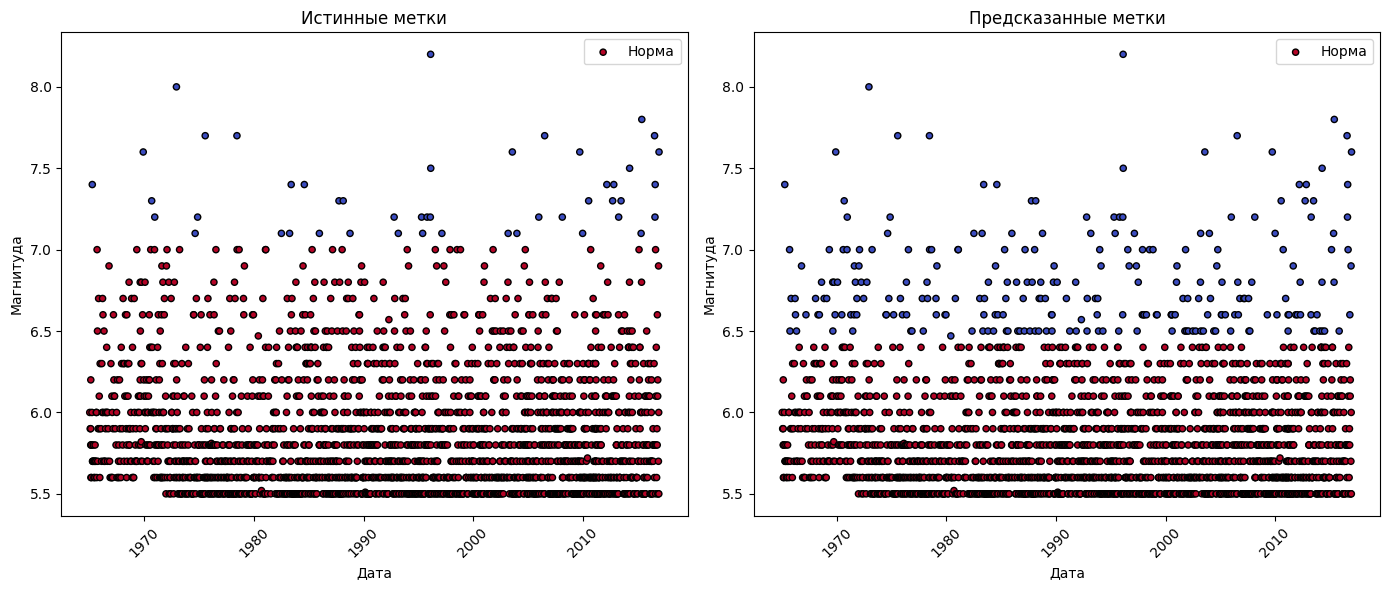


Статистика аномалий:
Количество аномалий: 2306
Максимальная магнитуда: 9.1
Средняя магнитуда: 5.88
Стандартное отклонение: 0.42


In [44]:
#Метрики Аномалий
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import IsolationForest
from datetime import datetime

# Загрузка данных
data = pd.read_csv('database.csv')

# Функция преобразования даты
def convert_date(date_str):
    try:
        return pd.to_datetime(date_str, format='%m/%d/%Y')
    except ValueError:
        return pd.NaT

# Преобразование и очистка данных
data['Date'] = data['Date'].apply(convert_date)
data = data.dropna(subset=['Date', 'Magnitude'])

# Подготовка данных для анализа
X = data[['Magnitude']].values.reshape(-1, 1)

# Создаем метки аномалий (магнитуды выше 7.0 считаем аномальными)
y_true = np.where(X.flatten() > 7.0, -1, 1)

# Обучение модели Isolation Forest
clf = IsolationForest(contamination=0.1, random_state=42)
y_pred = clf.fit_predict(X)

# Преобразование меток предсказаний
y_pred = np.where(y_pred == 1, 1, -1)

# Вычисление метрик
conf_matrix = confusion_matrix(y_true, y_pred)
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, pos_label=-1)
recall = recall_score(y_true, y_pred, pos_label=-1)
f1 = f1_score(y_true, y_pred, pos_label=-1)

# Вывод метрик
print("Confusion Matrix:\n", conf_matrix)
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

# Уменьшаем количество точек для визуализации
step = 10  # показывать каждую 10-ю точку

# Визуализация результатов
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.scatter(data['Date'][::step], data['Magnitude'][::step],
            c=y_true[::step], cmap='coolwarm', edgecolor='k', s=20)
plt.title('Истинные метки')
plt.xlabel('Дата')
plt.ylabel('Магнитуда')
plt.xticks(rotation=45)
plt.legend(['Норма', 'Аномалия'])

plt.subplot(1, 2, 2)
plt.scatter(data['Date'][::step], data['Magnitude'][::step],
            c=y_pred[::step], cmap='coolwarm', edgecolor='k', s=20)
plt.title('Предсказанные метки')
plt.xlabel('Дата')
plt.ylabel('Магнитуда')
plt.xticks(rotation=45)
plt.legend(['Норма', 'Аномалия'])

plt.tight_layout()
plt.show()

# Статистика аномалий
anomalies = data[y_pred == -1]
print("\nСтатистика аномалий:")
print(f"Количество аномалий: {len(anomalies)}")
print(f"Максимальная магнитуда: {data['Magnitude'].max()}")
print(f"Средняя магнитуда: {data['Magnitude'].mean():.2f}")
print(f"Стандартное отклонение: {data['Magnitude'].std():.2f}")

In [24]:
!pip install pyod

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 219.8/219.8 kB 11.7 MB/s eta 0:00:00


In [26]:
# Обнаружение выбросов на основе углов.
import numpy as np
import pandas as pd
import plotly.express as px
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import MinMaxScaler

# Загрузка данных
data = pd.read_csv('database.csv')

# Обработка данных
X = data[['Magnitude']].values

# Создаем искусственные признаки для визуализации (частота магнитуд)
magnitude_bins = np.linspace(X.min(), X.max(), 10)
X_binned = np.digitize(X, bins=magnitude_bins)

# Добавляем второй признак - частоту
from collections import Counter
freq = Counter(X_binned.flatten())
X_freq = np.array([freq[bin] for bin in X_binned.flatten()])

# Формируем двумерный массив для модели
X_2d = np.column_stack((X_binned.flatten(), X_freq))

# Обучение модели Isolation Forest
clf = IsolationForest(contamination=0.1)  # Убрали random_state
clf.fit(X_2d)

# Предсказание аномалий
y_pred = clf.predict(X_2d)
y_pred = np.where(y_pred == 1, 0, 1)  # Преобразуем в 0/1 формат

# Нормализация оценок для визуализации
scores = clf.decision_function(X_2d)
scaler = MinMaxScaler()
scores_scaled = scaler.fit_transform(scores.reshape(-1, 1)).flatten()

# Подготовка данных для визуализации
df = pd.DataFrame({
    'Magnitude': X.flatten(),
    'Frequency': X_freq,
    'Anomaly': y_pred,
    'Score': scores_scaled
})

# Визуализация результатов
fig = px.scatter(
    df,
    x='Magnitude',
    y='Frequency',
    color='Anomaly',
    size='Score',
    title='Обнаружение аномалий в частоте магнитуд землетрясений',
    hover_data=['Magnitude', 'Frequency', 'Score'],
    labels={
        'Magnitude': 'Магнитуда',
        'Frequency': 'Частота',
        'Anomaly': 'Аномалия',
        'Score': 'Оценка аномальности'
    }
)

fig.update_traces(
    marker=dict(
        opacity=0.7,
        line=dict(width=1, color='DarkSlateGrey')
    )
)

fig.show()

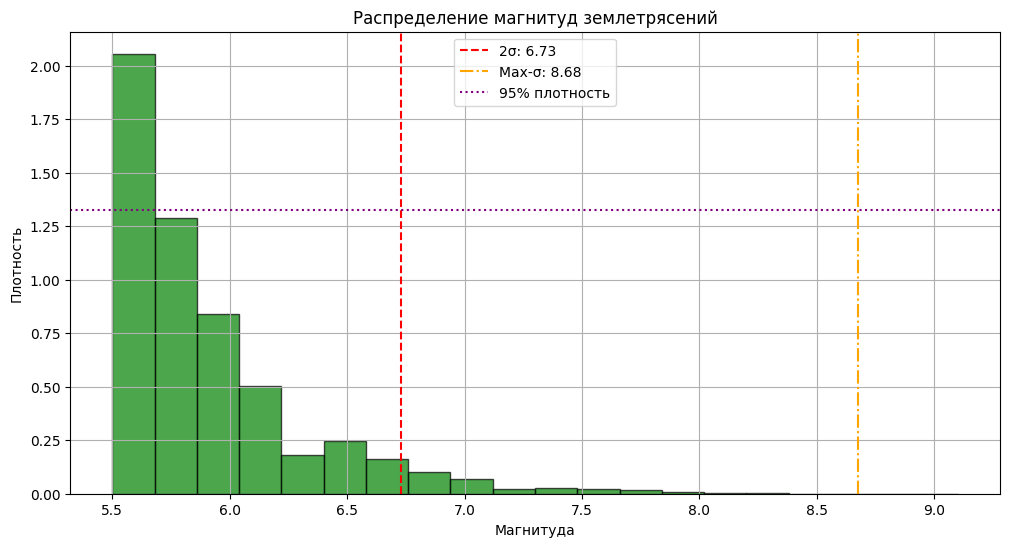

Статистика аномалий:
Пороговые значения:
  2σ порог: 6.73
  Max-σ порог: 8.68

Количество аномалий:
  По 2σ: 1161
  По Max-σ: 4


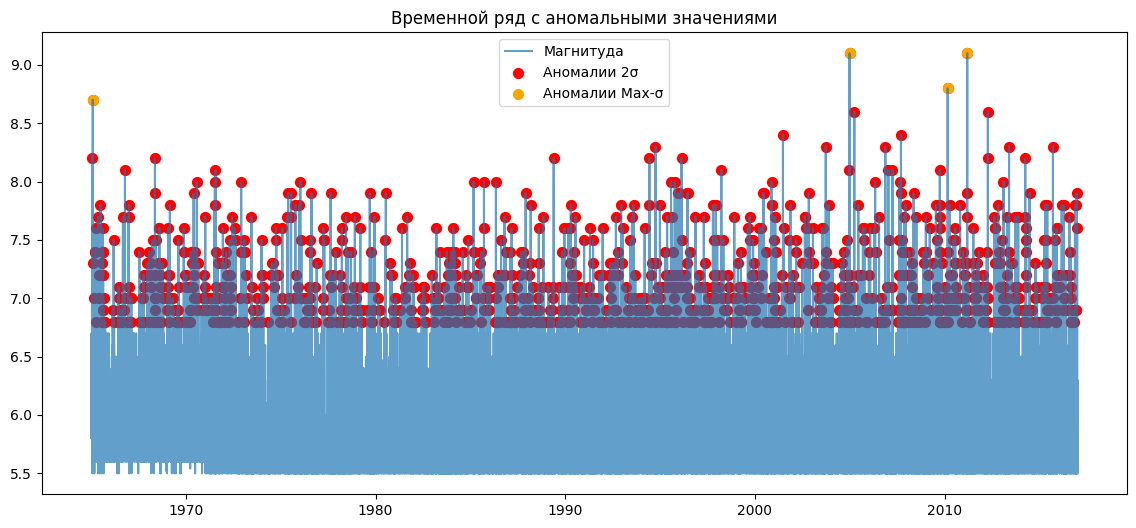

In [34]:
# Гистограмма
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

# Загрузка данных
data = pd.read_csv('database.csv')

# Преобразование даты
def convert_date(date_str):
    try:
        return pd.to_datetime(date_str, format='%m/%d/%Y')
    except ValueError:
        return pd.NaT

data['Date'] = data['Date'].apply(convert_date)
data = data.dropna(subset=['Date', 'Magnitude'])

# Строим гистограмму
plt.figure(figsize=(12, 6))
counts, bins, bars = plt.hist(data['Magnitude'], bins=20, density=True, alpha=0.7, color='g', edgecolor='k')
plt.title('Распределение магнитуд землетрясений')
plt.xlabel('Магнитуда')
plt.ylabel('Плотность')

# Находим центры бинов
bin_centers = 0.5 * (bins[:-1] + bins[1:])

# Определяем порог аномалий разными способами
# 1. По 95-му процентилю плотности
threshold_density = np.percentile(counts, 95)

# 2. По стандартному отклонению
mean_mag = data['Magnitude'].mean()
std_mag = data['Magnitude'].std()
threshold_std = mean_mag + 2 * std_mag

# 3. По максимальному значению минус 1 сигма
max_mag = data['Magnitude'].max()
threshold_max = max_mag - std_mag

# Визуализируем все пороги
plt.axvline(x=threshold_std, color='r', linestyle='--', label=f'2σ: {threshold_std:.2f}')
plt.axvline(x=threshold_max, color='orange', linestyle='-.', label=f'Max-σ: {threshold_max:.2f}')
plt.axhline(y=threshold_density, color='purple', linestyle=':', label=f'95% плотность')

# Выделяем аномальные значения
anomalies_std = data[data['Magnitude'] > threshold_std]
anomalies_max = data[data['Magnitude'] > threshold_max]

# Добавляем легенду
plt.legend()
plt.grid(True)
plt.show()

# Статистика по аномалиям
print("Статистика аномалий:")
print(f"Пороговые значения:")
print(f"  2σ порог: {threshold_std:.2f}")
print(f"  Max-σ порог: {threshold_max:.2f}")
print(f"\nКоличество аномалий:")
print(f"  По 2σ: {len(anomalies_std)}")
print(f"  По Max-σ: {len(anomalies_max)}")

# Визуализация на временном ряде
plt.figure(figsize=(14, 6))
plt.plot(data['Date'], data['Magnitude'], label='Магнитуда', alpha=0.7)
plt.scatter(anomalies_std['Date'], anomalies_std['Magnitude'], color='red', label='Аномалии 2σ', s=50)
plt.scatter(anomalies_max['Date'], anomalies_max['Magnitude'], color='orange', label='Аномалии Max-σ', s=50)
plt.title('Временной ряд с аномальными значениями')
plt.legend()
plt.show()

In [5]:
# Детектор K-Nearest Neighbors.
import numpy as np
import pandas as pd
import plotly.express as px
from pyod.models.knn import KNN
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from datetime import datetime

# Загрузка данных
data = pd.read_csv('database.csv')

# Преобразование даты
def convert_date(date_str):
    try:
        return pd.to_datetime(date_str, format='%m/%d/%Y')
    except ValueError:
        return pd.NaT

data['Date'] = data['Date'].apply(convert_date)
data = data.dropna(subset=['Date', 'Magnitude'])

# Подготовка данных для анализа
X = data[['Magnitude']].values

# Определение процента аномалий
contamination = len(data[data['Magnitude'] > 7]) / len(data)

# Обучение модели KNN
clf = KNN(contamination=contamination)
clf.fit(X)

# Предсказание аномалий
y_pred = clf.predict(X)  # 1 - аномалия, 0 - нормальное значение
y_scores = clf.decision_scores_

# Нормализация оценок
scaler = MinMaxScaler()
scores_scaled = scaler.fit_transform(y_scores.reshape(-1, 1)).flatten()

# Создание DataFrame для визуализации
df = pd.DataFrame({
    'Date': data['Date'],
    'Magnitude': data['Magnitude'],
    'Anomaly': y_pred,
    'Score': scores_scaled
})

# Метрики качества
y_true = (data['Magnitude'] > 7).astype(int)
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("Метрики качества:")
print(f"Точность: {accuracy:.2f}")
print(f"Прецизионность: {precision:.2f}")
print(f"Полнота: {recall:.2f}")
print(f"F1-score: {f1:.2f}")

# Визуализация с кастомной цветовой схемой
fig = px.scatter(
    df,
    x='Date',
    y='Magnitude',
    color='Anomaly',
    size='Score',
    title='Обнаружение аномалий магнитуд землетрясений (KNN)',
    hover_data=['Magnitude', 'Score']
)

# Настраиваем цвета: темные для обычных, красные для аномалий
fig.update_traces(
    marker=dict(
        color=np.where(df['Anomaly'] == 1, 'red', 'darkgray'),
        size=df['Score']*100  # увеличиваем размер точек
    )
)

fig.update_layout(
    xaxis_title='Дата',
    yaxis_title='Магнитуда',
    legend_title='Аномалия'
)
fig.show()

# Статистика аномалий
anomalies = df[df['Anomaly'] == 1]
print("\nСтатистика аномалий:")
print(f"Количество аномалий: {len(anomalies)}")
print(f"Максимальная магнитуда: {df['Magnitude'].max()}")
print(f"Средняя магнитуда: {df['Magnitude'].mean():.2f}")
print(f"Стандартное отклонение: {df['Magnitude'].std():.2f}")

# Фильтрация аномалий
strong_earthquakes = df[df['Magnitude'] > 7]
print("\nСильные землетрясения (магнитуда > 7):")
print(strong_earthquakes[['Date', 'Magnitude']].head(10))

Метрики качества:
Точность: 0.97
Прецизионность: 0.16
Полнота: 0.01
F1-score: 0.03



Статистика аномалий:
Количество аномалий: 50
Максимальная магнитуда: 9.1
Средняя магнитуда: 5.88
Стандартное отклонение: 0.42

Сильные землетрясения (магнитуда > 7):
          Date  Magnitude
11  1965-01-24        8.2
16  1965-02-04        8.7
26  1965-02-04        7.3
87  1965-03-14        7.4
100 1965-03-28        7.4
103 1965-03-30        7.6
152 1965-05-20        7.7
165 1965-06-11        7.2
193 1965-07-02        7.8
214 1965-08-02        7.3
